# Retrain the MMSplice architecture for ESL cell line data.

In [1]:
"""
Retrain the MMSplice architecture for ESL cell line data.

Made by Gabriel Fonseca and Angela Yu

GPL License

"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
import scipy.stats as stats
import seaborn as sns
from sklearn import preprocessing
import random
import pickle
from collections import defaultdict
import os
import keras_tuner as kerastuner
from toolz import interleave
from itertools import chain
from scipy.stats import linregress
from tensorflow.keras.optimizers import Adam
from tensorflow.python.keras.engine.functional import Functional
from tensorflow.keras import regularizers

#from tensorflow import keras
#import keras
import tensorflow as tf
np.random.seed(1337)

%matplotlib inline

### Parameters for plotting model results ###
pd.set_option("display.max_colwidth",100)
sns.set(style="ticks", color_codes=True)
plt.rcParams['font.weight'] = 'normal'
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.labelpad'] = 5
plt.rcParams['axes.linewidth']= 1.5
plt.rcParams['xtick.labelsize']= 14
plt.rcParams['ytick.labelsize']= 14
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.minor.width'] = 1
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['axes.edgecolor'] = 'black'


def one_hot_encode(sequences, max_seq_len=164, mask_val=-1, padding='left'):
    # Dictionary returning one-hot encoding of nucleotides. 
    nuc_d = {'a':[1,0,0,0],
             'c':[0,1,0,0],
             'g':[0,0,1,0],
             't':[0,0,0,1],
             'n':[0,0,0,0],
            'm':[mask_val,mask_val,mask_val,mask_val]}
    
    # Creat empty matrix
    one_hot_seqs = np.ones([len(sequences), max_seq_len, 4])*mask_val
    
    # Iterate through sequences and one-hot encode
    for i, seq in enumerate(sequences):
        # Truncate
        seq = seq[:max_seq_len].lower()
        # Convert to array
        one_hot_seq = np.array([nuc_d[x] for x in seq])
        # Append to matrix
        if padding=='left':
            one_hot_seqs[i, :len(seq), :] = one_hot_seq
        elif padding=='right':
            one_hot_seqs[i, -len(seq):, :] = one_hot_seq
        else:
            ValueError(f'padding {padding} not recognized')
            
    return one_hot_seqs


def r2(x,y):
    slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)
    return r_value**2


def calc_r(x,y):
    slope, intercept, r_value, p_value, std_err = linregress(x,y)
    return r_value


def clip(x, clip_threshold=0.00001):
    return np.clip(x, clip_threshold, 1 - clip_threshold)


def logit(x, clip_threshold=0.00001):
    x = clip(x, clip_threshold=clip_threshold)
    return np.log(x) - np.log(1 - x)
    
    
def expit(x):
    return 1. / (1. + np.exp(-x))


def create_directory(directory):
    """
        Create the output directory if it does not already exist.
        Return: The name of the directory.
    """
    if not os.path.exists(directory):
        os.makedirs(directory)
    return directory



2025-09-08 09:55:13.859701: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1


## Define Model

In [2]:
"""
Reimplementing MMSplice.layer's GlobalAveragePooling1D_Mask0 class.
This is for saving the full model, and their version doesn't have get_config().
https://stackoverflow.com/questions/58678836/notimplementederror-layers-with-arguments-in-init-must-override-get-conf
"""
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K
from layers import normalize_data_format  # soft linked to MMSplice's layers.py


class GlobalAveragePooling1D_Mask0(Layer):
    """
    Global average pooling operation for temporal data.
    Masking out 0-padded input.
    """

    
    def __init__(self, data_format='channels_last', **kwargs):
        super(GlobalAveragePooling1D_Mask0, self).__init__(**kwargs)
        self.data_format = normalize_data_format(data_format)

        
    def compute_output_shape(self, input_shape):
        input_shape = input_shape[0]
        if self.data_format == 'channels_first':
            return (input_shape[0], input_shape[1])
        else:
            return (input_shape[0], input_shape[2])

        
    def call(self, inputs):
        inputs, model_inputs = inputs
        steps_axis = 1 if self.data_format == 'channels_last' else 2
        mask = K.max(model_inputs, axis=2, keepdims=True)
        inputs *= mask
        return K.sum(inputs, axis=steps_axis) / K.maximum(
            K.sum(mask, axis=steps_axis), K.epsilon())
    
    
    def get_config(self):
        config = super().get_config().copy()
        config.update({
            'data_format': self.data_format
        })
        return config
    
    

In [3]:
"""
Rebuild MMSplice in tensorflow2 framework (i.e. no numpy for top layer and alt+ref module handling)
"""

from tensorflow.keras.models import load_model
from tensorflow.keras.layers import concatenate, Subtract, Dense, Layer
from tensorflow.keras import Model, Input
from layers import ConvDNA  # soft linked to MMSplice's layers.py


def convert_tf_bool_float(x, suffix=None):
    if suffix is None:
        return tf.where(x, 1.0, 0.0)
    else:
        return tf.where(x, 1.0, 0.0, name="where_"+suffix)


"""
Based on related functions in MMSplice.utils which depends on np.isclose.
Because comparing to 0, (rtol * abs(b)) where b = 0 and therefore the same as 0.
"""
def and_not_close0(x, y, return_bool=False, suffix=None):
    if suffix is None:
        logic_result = tf.math.logical_and(x != 0, y != 0)
    else:
        logic_result = tf.math.logical_and(x != 0, y != 0, name="logical_and_"+suffix)
    if return_bool:
        return logic_result
    return convert_tf_bool_float(logic_result, suffix=suffix)


def logit_tensor(x, clip_threshold=0.00001, suffix=None):
    if suffix is None:
        x = tf.clip_by_value(x, clip_value_min=clip_threshold, clip_value_max=1-clip_threshold)
        return tf.math.log(x) - tf.math.log(1 - x)
    else:
        x = tf.clip_by_value(x, clip_value_min=clip_threshold, clip_value_max=1-clip_threshold, name="clip_by_value_"+suffix)
        return tf.math.log(x, name="log_p_"+suffix) - tf.math.log(1 - x, name="log_1mp_"+suffix)

    
"""
Based on this: https://gist.github.com/nrasadi/60d40447caf5ad1e1b0785c7e1b0234a#file-tfkeras_model_add_prefix-py
"""
def rename_pretrained_model(model, suffix, custom_objects=None):
    config = model.get_config()
    old_to_new = {}
    new_to_old = {}
    
    for layer in config['layers']:
        new_name = layer['name'] + suffix
        old_to_new[layer['name']], new_to_old[new_name] = new_name, layer['name']
        layer['name'] = new_name
        layer['config']['name'] = new_name

        if len(layer['inbound_nodes']) > 0:
            for in_node in layer['inbound_nodes'][0]:
                in_node[0] = old_to_new[in_node[0]]
    
    for input_layer in config['input_layers']:
        input_layer[0] = old_to_new[input_layer[0]]
    
    for output_layer in config['output_layers']:
        output_layer[0] = old_to_new[output_layer[0]]
    
    config['name'] = config['name'] + suffix
    new_model = tf.keras.Model().from_config(config, custom_objects)
    
    for layer in new_model.layers:
        layer.set_weights(model.get_layer(new_to_old[layer.name]).get_weights())
    
    return new_model


def MMSplice_build_subtree(suffix=None, trainable_modules=False, original_MMSplice_models_dir = ""):
    if suffix is None:
        suffix = ""
    
    custom_objects = {
        'ConvDNA': ConvDNA
    }

    acceptor_intronM = original_MMSplice_models_dir + "Intron3.h5"
    acceptorM = original_MMSplice_models_dir + "Acceptor.h5"
    exonM = original_MMSplice_models_dir + "Exon.h5"
    exon3pM = original_MMSplice_models_dir + "Exon_prime3.h5"
    donorM = original_MMSplice_models_dir + "Donor.h5"
    donor_intronM = original_MMSplice_models_dir + "Intron5.h5"

    acceptor_intron_model = load_model(acceptor_intronM, compile=False, custom_objects=custom_objects)
    acceptor_model = load_model(acceptorM, compile=False, custom_objects=custom_objects)
    exon_model = load_model(exonM, compile=False, custom_objects={
                "GlobalAveragePooling1D_Mask0": GlobalAveragePooling1D_Mask0,
                'ConvDNA': ConvDNA
            })
    donor_model = load_model(donorM, compile=False, custom_objects=custom_objects)
    donor_intron_model = load_model(donor_intronM, compile=False, custom_objects=custom_objects)

    # rebuild with renamed internal names
    acceptor_intron_model = rename_pretrained_model(acceptor_intron_model, "_acceptor_intron_" + suffix, custom_objects=custom_objects)
    acceptor_model = rename_pretrained_model(acceptor_model, "_acceptor_" + suffix, custom_objects=custom_objects)
    exon_model = rename_pretrained_model(exon_model, "_exon_" + suffix, custom_objects={
                "GlobalAveragePooling1D_Mask0": GlobalAveragePooling1D_Mask0,
                'ConvDNA': ConvDNA
            })
    donor_model = rename_pretrained_model(donor_model, "_donor_" + suffix, custom_objects=custom_objects)
    donor_intron_model = rename_pretrained_model(donor_intron_model, "_donor_intron_" + suffix, custom_objects=custom_objects)
    
    if not trainable_modules:
        acceptor_intron_model.trainable = False
        acceptor_model.trainable = False
        exon_model.trainable = False
        donor_model.trainable = False
        donor_intron_model.trainable = False

    return acceptor_intron_model, acceptor_model, exon_model, donor_model, donor_intron_model


def get_saved_model():
    saved_model_path = "/storage/yu/Projects/P000--ESL_continuation/GitHub/MMSplice_MTSplice/mmsplice/models/"

    acceptor_intron_model_ref, acceptor_model_ref, exon_model_ref, donor_model_ref, donor_intron_model_ref = \
        MMSplice_build_subtree("ref", trainable_modules=True, original_MMSplice_models_dir=saved_model_path)

    reference_seqs = [Input(shape=(None, 4), name="input_intron3p_ref"), \
                      Input(shape=(53, 4), name="input_acceptor_ref"), \
                      Input(shape=(None, 4), name="input_exon_ref"), \
                      Input(shape=(18, 4), name="input_donor_ref"), \
                      Input(shape=(None, 4), name="input_intron5p_ref")]
    alternative_seqs = [Input(shape=(None, 4), name="input_intron3p_alt"), \
                      Input(shape=(53, 4), name="input_acceptor_alt"), \
                      Input(shape=(None, 4), name="input_exon_alt"), \
                      Input(shape=(18, 4), name="input_donor_alt"), \
                      Input(shape=(None, 4), name="input_intron5p_alt")]
    print("reference_seqs+alternative_seqs = ", reference_seqs+alternative_seqs)

    suffix = "ref"
    combined_ref = concatenate([acceptor_intron_model_ref(reference_seqs[0]), \
                                logit_tensor(acceptor_model_ref(reference_seqs[1]), suffix="acceptor_"+suffix), \
                                     exon_model_ref(reference_seqs[2]), \
                                logit_tensor(donor_model_ref(reference_seqs[3]), suffix="acceptor_"+suffix), \
                                     donor_intron_model_ref(reference_seqs[4])], name="concatenate_modules_" + suffix)
    suffix = "alt"
    combined_alt = concatenate([acceptor_intron_model_ref(alternative_seqs[0]), \
                                logit_tensor(acceptor_model_ref(alternative_seqs[1]), suffix="acceptor_"+suffix), \
                                     exon_model_ref(alternative_seqs[2]), \
                                logit_tensor(donor_model_ref(alternative_seqs[3]), suffix="acceptor_"+suffix), \
                                     donor_intron_model_ref(alternative_seqs[4])], name="concatenate_modules_" + suffix)

    subtract_alt_ref_modules = Subtract(name = "subtract_alt_ref_modules")( \
        [combined_alt, combined_ref])
    print("subtract_alt_ref_modules = ", subtract_alt_ref_modules)
    print("subtract_alt_ref_modules[:, 2] = ", subtract_alt_ref_modules[:, 2])
    print("tf.gather(subtract_alt_ref_modules, [2], axis=1) = ", tf.gather(subtract_alt_ref_modules, [2], axis=1))

    # add interaction terms
    acceptor_intron_diff_output = tf.gather(subtract_alt_ref_modules, [0], axis=1, name="gather_acceptor_intron_diff")
    acceptor_diff_output = tf.gather(subtract_alt_ref_modules, [1], axis=1, name="gather_acceptor_diff")
    exon_diff_output = tf.gather(subtract_alt_ref_modules, [2], axis=1, name="gather_exon_diff")
    donor_diff_output = tf.gather(subtract_alt_ref_modules, [3], axis=1, name="gather_donor_diff")
    donor_intron_diff_output = tf.gather(subtract_alt_ref_modules, [4], axis=1, name="gather_donor_intron_diff")

    exon_overlap = tf.math.logical_or(and_not_close0(acceptor_diff_output, exon_diff_output, return_bool=True, suffix="exon_overlap_acceptor"), \
                                      and_not_close0(exon_diff_output, donor_diff_output, return_bool=True, suffix="exon_overlap_donor"), \
                                     name="exon_overlap_logical_or")
    donor_intron_overlap = and_not_close0(donor_diff_output, donor_intron_diff_output, suffix="donor_overlap_acceptor")
    acceptor_intron_overlap_indicator = and_not_close0(acceptor_intron_diff_output, acceptor_diff_output, suffix="acceptor_overlap_acceptor")

    exon_overlap = tf.keras.layers.Multiply(name = "exon_overlap")([exon_diff_output, convert_tf_bool_float(exon_overlap)])
    donor_intron_overlap = tf.keras.layers.Multiply(name = "donor_intron_overlap")([donor_intron_diff_output, donor_intron_overlap])
    acceptor_intron_overlap = tf.keras.layers.Multiply(name = "acceptor_intron_overlap")([acceptor_intron_diff_output, acceptor_intron_overlap_indicator])

    combined_full = concatenate([subtract_alt_ref_modules, exon_overlap, donor_intron_overlap, acceptor_intron_overlap], name="concatenate_modules_overlaps")
    combined_full = Dense(1, activation="linear")(combined_full)

    merged_MMSplice_full = Model(inputs=reference_seqs+alternative_seqs, \
                            outputs=[combined_full])

    """
    Set weights based on MMSplice's linear layer
    Technically transposed matrix, but is equivalent.
    """

    linear_coeff_prior = np.array([[0.49685773], [0.72322957], [1.54760024],
                                  [0.75011527], [2.26187717],  [-0.69419094],
                                  [2.40138709],  [0.88148553]])
    linear_intercept_prior = np.array([0.0006480262366686865])
    merged_MMSplice_full.layers[-1].set_weights([linear_coeff_prior, linear_intercept_prior])
    return merged_MMSplice_full


# Create two copies, to hyperparameter tune later
mm_splice_saved = get_saved_model()
merged_MMSplice_full = get_saved_model()
print("merged_MMSplice_full.summary() = ", merged_MMSplice_full.summary())
print("merged_MMSplice_full.layers[-1].get_weights() = ", merged_MMSplice_full.layers[-1].get_weights())

2025-09-08 09:55:26.175331: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2025-09-08 09:55:26.177273: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2025-09-08 09:55:26.234885: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:59:00.0 name: Quadro RTX 5000 computeCapability: 7.5
coreClock: 1.815GHz coreCount: 48 deviceMemorySize: 15.73GiB deviceMemoryBandwidth: 417.29GiB/s
2025-09-08 09:55:26.234947: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1
2025-09-08 09:55:26.237994: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcublas.so.10
2025-09-08 09:55:26.238066: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcublasLt.so.10
2025-

reference_seqs+alternative_seqs =  [<KerasTensor: shape=(None, None, 4) dtype=float32 (created by layer 'input_intron3p_ref')>, <KerasTensor: shape=(None, 53, 4) dtype=float32 (created by layer 'input_acceptor_ref')>, <KerasTensor: shape=(None, None, 4) dtype=float32 (created by layer 'input_exon_ref')>, <KerasTensor: shape=(None, 18, 4) dtype=float32 (created by layer 'input_donor_ref')>, <KerasTensor: shape=(None, None, 4) dtype=float32 (created by layer 'input_intron5p_ref')>, <KerasTensor: shape=(None, None, 4) dtype=float32 (created by layer 'input_intron3p_alt')>, <KerasTensor: shape=(None, 53, 4) dtype=float32 (created by layer 'input_acceptor_alt')>, <KerasTensor: shape=(None, None, 4) dtype=float32 (created by layer 'input_exon_alt')>, <KerasTensor: shape=(None, 18, 4) dtype=float32 (created by layer 'input_donor_alt')>, <KerasTensor: shape=(None, None, 4) dtype=float32 (created by layer 'input_intron5p_alt')>]
subtract_alt_ref_modules =  KerasTensor(type_spec=TensorSpec(shape

## Load Data

In [4]:
splice_vs_super = pd.read_csv("/storage/yu/Projects/P000--ESL_continuation/Data/MMSplice_2025_07_23/mmsplice_vs_supertable.csv")

In [5]:
splice_vs_super

,MMSplice_Ref_ID,MMSplice_VCF_Variant,region,MMSplice_Delta_Logit_PSI,Supertable_Mean_Delta_Logit_PSI,WT_Avg_PSI,WT_Avg_Logit,MMSplice_Predicted_PSI,Supertable_Observed_PSI,MMSplice_Predicted_Delta_PSI,...,Reference,event_id,gene_exon,snp,source,seq_type,intron1,exon,intron2,full_seq
0,1:791:C>A,10:C>A,intronic,-0.370316,0.000000,0.001130,-4.595120,0.006927,0.000000,0.005797,...,32,chr10:101775110-101775270:-,FGF8 exon 3,10:C>A,clinvar_single,single,TGTCAGGGGTAGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAG,GAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCTTCCCTGTTCCGGGCTGGCCGGGAGCCCCAGGGTGTCTCCCAACAG,GTGGGTCCAGCTTCTCCCTG,TGTCAGGGGTAGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAGGAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCT...
1,1:881:T>C,100:T>C,exonic,0.147751,0.000000,0.000923,-4.595120,0.011574,0.000000,0.010651,...,301,chr10:101775110-101775270:-,FGF8 exon 3,100:T>C,clinvar_single,single,TGTCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAG,GAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCTTCCCCGTTCCGGGCTGGCCGGGAGCCCCAGGGTGTCTCCCAACAG,GTGGGTCCAGCTTCTCCCTG,TGTCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAGGAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCT...
2,1:892:G>A,111:G>A,exonic,-0.253154,0.000000,0.000923,-4.595120,0.007781,0.000000,0.006858,...,333,chr10:101775110-101775270:-,FGF8 exon 3,111:G>A,clinvar_single,single,TGTCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAG,GAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCTTCCCTGTTCCGGGCTAGCCGGGAGCCCCAGGGTGTCTCCCAACAG,GTGGGTCCAGCTTCTCCCTG,TGTCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAGGAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCT...
3,1:896:G>A,115:G>A,exonic,0.109977,0.000000,0.001580,-4.595120,0.011150,0.000000,0.009569,...,345,chr10:101775110-101775270:-,FGF8 exon 3,115:G>A,clinvar_single,single,TGTCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAG,GAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCTTCCCTGTTCCGGGCTGGCCAGGAGCCCCAGGGTGTCTCCCAACAG,GTGGGTCCAGCTTCTCCCTG,TGTCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAGGAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCT...
4,1423:781:A>G,0:A>G,intronic,-0.130749,0.022101,0.977727,3.907197,0.977609,0.975961,-0.000118,...,1426,chr10:6019850-6020010:-,IL2RA exon 5,0:A>G,clinvar_single,single,GGGCGGGGTGGGAGTGAGGCCCTGACTCCTGTGTTTAGCTCCACCAGCATCACTTACTCTCTCCCCCAG,GTGAAGAGAAGCCTCAGGCAAGCCCCGAAGGCCGTCCTGAGAGTGAGACTTCCTGCCTCGTCACAACAACAG,GTGCGGGAGAAGACAAACGC,GGGCGGGGTGGGAGTGAGGCCCTGACTCCTGTGTTTAGCTCCACCAGCATCACTTACTCTCTCCCCCAGGTGAAGAGAAGCCTCAGGCAAGCCCCG...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29564,85886:915:C>A,134:C>A,exonic,-0.081185,1.225196,0.019973,-3.901982,0.018286,0.074153,-0.001687,...,107176,chrX:153921077-153921237:-,ARHGAP4 exon 4,134:C>A,exac,single,CTTGATCTGGGCAGAGCTTCCAGTGCCTGGCGGGGCCGCTCTGGGCAGTGCCGTGCTCACCCTTGCCTCTGCCTCTAG,AGCAGGGATCTGGAGCAGCAGCTGCAGGATGAGCTCCTGGAGGTGGTCTCAGAGCTACAGACG,GTGAGGAAAGGGCTGGGGAG,CTTGATCTGGGCAGAGCTTCCAGTGCCTGGCGGGGCCGCTCTGGGCAGTGCCGTGCTCACCCTTGCCTCTGCCTCTAGAGCAGGGATCTGGAGCAG...
29565,85886:920:C>A,139:C>A,donor,0.162795,2.581740,0.019973,-3.901982,0.023221,0.229281,0.003249,...,107174,chrX:153921077-153921237:-,ARHGAP4 exon 4,139:C>A,exac,single,CTTGATCTGGGCAGAGCTTCCAGTGCCTGGCGGGGCCGCTCTGGGCAGTGCCGTGCTCACCCTTGCCTCTGCCTCTAG,AGCAGGGATCTGGAGCAGCAGCTGCAGGATGAGCTCCTGGAGGTGGTCTCAGAGCTCCAGAAG,GTGAGGAAAGGGCTGGGGAG,CTTGATCTGGGCAGAGCTTCCAGTGCCTGGCGGGGCCGCTCTGGGCAGTGCCGTGCTCACCCTTGCCTCTGCCTCTAGAGCAGGGATCTGGAGCAG...
29566,85891:884:T>G,103:T>G,exonic,1.012612,1.799308,0.842313,1.756690,0.940994,0.960457,0.098681,...,107225,chrX:154789934-154790094:-,MPP1 exon 5,103:T>G,exac,single,GGGACTTTGAATGAATGATCACATCATTCAACTTAGTTTTCTGTACAATTTTATGTCCATTTTTTTTAATAG,AAAGAAACCAAAGGAATGATCTCATTAAAAGGAATTCCCAACCAGCAAAGCCGTCTTCCTGCACTACAG,GTGGGTGGCACCATTTTCTC,GGGACTTTGAATGAATGATCACATCATTCAACTTAGTTTTCTGTACAATTTTATGTCCATTTTTTTTAATAGAAAGAAACCAAAGGAATGATCTCA...
29567,85891:890:C>A,109:C>A,exonic,0.099289,0.068372,0.842313,1.756690,0.864828,0.838788,0.022514,...,107223,chrX:154789934-154790094:-,MPP1 exon 5,109:C>A,

In [6]:
splice_vs_super_double_variants = pd.read_csv("/storage/yu/Projects/P000--ESL_continuation/Data/MMSplice_2025_07_23/double_variants/mmsplice_vs_supertable_vcfid_filtered.csv")

In [7]:
# Rename double variants data frame so it has the same column 
# names as the single variants data frame. Check the naming is 
# sound.
names1 = []
names2 = []
for i in splice_vs_super:
    names1.append(i)
for i in splice_vs_super_double_variants:
    names2.append(i)
splice_vs_super_double_variants=splice_vs_super_double_variants.rename(\
                columns = {names2[i] : names1[i] for i in range(len(names1))})
for i in range(len(names1)):
    print((names1[i], names2[i]))

('MMSplice_Ref_ID', 'MMsplice Ref ID')
('MMSplice_VCF_Variant', 'MMSplice VCF Var')
('region', 'region')
('MMSplice_Delta_Logit_PSI', 'delta_logit_psi')
('Supertable_Mean_Delta_Logit_PSI', 'mean_delta_logit_pooled')
('WT_Avg_PSI', 'wt_avg_psi')
('WT_Avg_Logit', 'wt_avg_logit')
('MMSplice_Predicted_PSI', 'predicted_variant_psi')
('Supertable_Observed_PSI', 'avg_variant_psi')
('MMSplice_Predicted_Delta_PSI', 'predicted_delta_psi')
('Supertable_Observed_Delta_PSI', 'experimental_delta_psi')
('HEK_Supertable_Delta_Logit', 'HEK_delta_logit_pooled')
('HeLa_Supertable_Delta_Logit', 'HeLa_delta_logit_pooled')
('K562_Supertable_Delta_Logit', 'K562_delta_logit_pooled')
('MCF7_Supertable_Delta_Logit', 'MCF7_delta_logit_pooled')
('HMC3_Supertable_Delta_Logit', 'HMC3_delta_logit_pooled')
('Reference', 'Reference')
('event_id', 'event_id')
('gene_exon', 'gene_exon')
('snp', 'snp')
('source', 'source')
('seq_type', 'seq_type')
('intron1', 'intron1')
('exon', 'exon')
('intron2', 'intron2')
('full_seq'

In [8]:
# "splice_vs_super_double_variants" has data from single variants as well
# so it is the full dataset
splice_vs_super_full = splice_vs_super_double_variants

In [9]:
splice_vs_super_full

,MMSplice_Ref_ID,MMSplice_VCF_Variant,region,MMSplice_Delta_Logit_PSI,Supertable_Mean_Delta_Logit_PSI,WT_Avg_PSI,WT_Avg_Logit,MMSplice_Predicted_PSI,Supertable_Observed_PSI,MMSplice_Predicted_Delta_PSI,...,Reference,event_id,gene_exon,snp,source,seq_type,intron1,exon,intron2,full_seq
0,32,10:C>A,intronic,-0.370317,0.000000,0.001130,-4.595120,0.006927,0.000000,0.005797,...,32,chr10:101775110-101775270:-,FGF8 exon 3,10:C>A,clinvar_single,single,TGTCAGGGGTAGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAG,GAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCTTCCCTGTTCCGGGCTGGCCGGGAGCCCCAGGGTGTCTCCCAACAG,GTGGGTCCAGCTTCTCCCTG,TGTCAGGGGTAGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAGGAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCT...
1,301,100:T>C,exonic,0.147752,0.000000,0.000923,-4.595120,0.011574,0.000000,0.010651,...,301,chr10:101775110-101775270:-,FGF8 exon 3,100:T>C,clinvar_single,single,TGTCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAG,GAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCTTCCCCGTTCCGGGCTGGCCGGGAGCCCCAGGGTGTCTCCCAACAG,GTGGGTCCAGCTTCTCCCTG,TGTCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAGGAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCT...
2,333,111:G>A,exonic,-0.253153,0.000000,0.000923,-4.595120,0.007781,0.000000,0.006858,...,333,chr10:101775110-101775270:-,FGF8 exon 3,111:G>A,clinvar_single,single,TGTCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAG,GAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCTTCCCTGTTCCGGGCTAGCCGGGAGCCCCAGGGTGTCTCCCAACAG,GTGGGTCCAGCTTCTCCCTG,TGTCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAGGAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCT...
3,345,115:G>A,exonic,0.109979,0.000000,0.001580,-4.595120,0.011150,0.000000,0.009570,...,345,chr10:101775110-101775270:-,FGF8 exon 3,115:G>A,clinvar_single,single,TGTCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAG,GAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCTTCCCTGTTCCGGGCTGGCCAGGAGCCCCAGGGTGTCTCCCAACAG,GTGGGTCCAGCTTCTCCCTG,TGTCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAGGAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCT...
4,961,1:T>A,intronic,-0.014864,0.186826,0.959444,3.512048,0.970608,0.961459,0.011163,...,961,chr10:125816157-125816317:-,UROS exon 3,1:T>A,clinvar_single,single,GATCCCTTATTTTAAAAACAGCCCTAGCCAATCCAGAACTATATTCTTTCATTTCAG,GAATTAGGATTATATGGACTTGAAGCCACTTTGATCCCTGTTTTATCGTTTGAGTTTTTGTCTCTTCCCAGTTTCTCTGAGAAG,GTAAGGCCTGTTGTGACTGA,GATCCCTTATTTTAAAAACAGCCCTAGCCAATCCAGAACTATATTCTTTCATTTCAGGAATTAGGATTATATGGACTTGAAGCCACTTTGATCCCT...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70539,243972,48:T>G ; 90:A>C,intronic,0.383538,2.664954,0.116273,-2.157483,0.145052,0.605868,0.028780,...,243972,chr2:71549251-71549411:+,DYSF exon 17,48:T>G ; 90:A>C,clinvar_double,double,TGTCTGCCTGCCAGCTCTCCATCCACAGCCTGTTCATGTAACCCGTCCGTCTCCCAGCCATGCCCACCCTAACCCCTTTTCCATTTCTTTCCGCTTCAG,AGGAGCCTGCAGGTGCTGTCAAGCCTTCGAAAGCCTCAGACT,GTACGTTGCTGTCACCTTGG,TGTCTGCCTGCCAGCTCTCCATCCACAGCCTGTTCATGTAACCCGTCCGTCTCCCAGCCATGCCCACCCTAACCCCTTTTCCATTTCTTTCCGCTT...
70540,243973,42:T>G ; 102:C>A,acceptor,-2.555702,-6.170220,0.977377,3.957494,0.802468,0.107993,-0.174909,...,243973,chr8:18069772-18069932:-,ASAH1 exon 4,42:T>G ; 102:C>A,clinvar_double,double,AATCTTGACAGCATTTCATTATGTCTTTTAGTAAGCATTTTAGTTATTTTTCAG,CTAAAGGTTATAGTGAATTCTCTGAAGAATATGATAAATACATTCGTGACAAGTGGAAAAATTATGCAGGTGGTGGATGAAAAATTG,GTAAGAGATATTATTTCTCA,AATCTTGACAGCATTTCATTATGTCTTTTAGTAAGCATTTTAGTTATTTTTCAGCTAAAGGTTATAGTGAATTCTCTGAAGAATATGATAAATACA...
70541,243975,18:A>C ; 96:G>C,intronic,-0.514516,-0.163719,0.621716,0.544739,0.507555,0.584387,-0.114161,...,243975,chr9:91216039-91216199:-,AUH exon 9,18:A>C ; 96:G>C,clinvar_double,double,TTGGGGATAAGGTTATTCCATTTGAATTTCTGTTGAATATACCACATTTCGCAAAGTTATTTCTGCTGAAATGGATTATGTTTTTATTCTCAG,GTCCATTTAGTAACAGGGTTAGCCATAGAAGAAGCTTGTTATGCTCAG,GTATGTAATGCAATCACAAA,TTGGGGATAAGGTTATTCCATTTGAATTTCTGTTGAATATACCACATTTCGCAAAGTTATTTCTGCTGAAATGGATTATGTTTTTATTCTCAGGTC...
70542,243986,72:G>A ; 150:C>T,exonic,0.068000,0.276051,0.919669,2.679337,0.939763,0.938164,0.020094,...,243986,chr15:27990556-27990

In [10]:
# Load PSI data from each cell line

# Defining inputs
SMN2_intron6 = "GTAAGTAATCACTCAGCATCTTTTCCTGACAATTTTTTTGTAGTTATGTGACTTTGTTTTGTAAATTTATAAAATACTACTTGCTTCTCTCTTTATATTACTAAAAAATAAAAATAAAAAAATACAACTGTCTGAGGCTTAAATTACTCTCAACTTAATTTCTGATCATATTTTGTTGAATAAAATAAGTAAAATGTCTTGTGAAACAAAATGCTTTTTAACATCCATATAAAGCTATCTATATATAGCTATCTATATCTA"
SMN2_intron7 = "AAAGTGAATCTTACTTTTGTAAAACTTTATGGTTTGTGGAAAACAAATGTTTTTGAACATTTAAAAAGTTCAGATGTTAGAAAGTTGAAAGGTTAATGTAAAACAATCAATATTAAAGAATTTTGATGCCAAAACTATTAGATAAAAGGTTAATCTACATCCCTACTAGAATTCTCATACTTAACTGGTTGGTTGTGTGGAAGAAACATACTTTCACAATAAAGAGCTTTAGGATATGATGCCATTTTATATCACTAGTAGGCAGACCAGCAGACTTTTTTTTATTGTGATATGGGATAACCTAGGCATACTGCACTGTACACTCTGACATATGAAGTGCTCTAGTCAAGTTTAACTGGTGTCCACAGAGGACATGGTTTAACTGGAATTCGTCAAGCCTCTGGTTCTAATTTCTCATTTGCAG"
supertable_file = "/storage/yu/Projects/P000--ESL_continuation/Figures_SK/General_preprocessing/fix_supertable_2/st_final_with_snp_and_coords_05_30_25.csv"
coverage_file = "/storage/yu/Projects/P000--ESL_continuation/Figures_SK/General_preprocessing/output_7_13_2025/07_18_2025_1e-2_ALL_WTS_VARS_NO_DELTAS.csv"
coverage_df = pd.read_csv(coverage_file)


### Get train/val/test splits based on coverage

In [11]:
# Data table with coverage info for each variant and reference.
# Want the train/val/test splits to assign the largest coverage
# samples to test and val, while mantaining some high coverage
# samples in train
coverage_df

,Reference,event_id,gene_exon,snp,source,seq_type,intron1,exon,intron2,full_seq,...,HEK_rep3_included,HEK_rep3_excluded,HEK_rep3_psi_raw,HEK_rep3_psi_clipped,HEK_rep3_logit,HEK_rep4_included,HEK_rep4_excluded,HEK_rep4_psi_raw,HEK_rep4_psi_clipped,HEK_rep4_logit
0,1,chr10:101775110-101775270:-,FGF8 exon 3,none,clinvar_single,none,TGTCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAG,GAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCTTCCCTGTTCCGGGCTGGCCGGGAGCCCCAGGGTGTCTCCCAACAG,GTGGGTCCAGCTTCTCCCTG,TGTCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAGGAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCT...,...,0.0,3617.0,0.0,0.01,-4.59512,0.0,4060.0,0.0,0.01,-4.59512
1,2,chr10:101775110-101775270:-,FGF8 exon 3,0:T>A,clinvar_single,single,AGTCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAG,GAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCTTCCCTGTTCCGGGCTGGCCGGGAGCCCCAGGGTGTCTCCCAACAG,GTGGGTCCAGCTTCTCCCTG,AGTCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAGGAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCT...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,chr10:101775110-101775270:-,FGF8 exon 3,0:T>C,clinvar_single,single,CGTCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAG,GAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCTTCCCTGTTCCGGGCTGGCCGGGAGCCCCAGGGTGTCTCCCAACAG,GTGGGTCCAGCTTCTCCCTG,CGTCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAGGAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCT...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,chr10:101775110-101775270:-,FGF8 exon 3,0:T>G,clinvar_single,single,GGTCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAG,GAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCTTCCCTGTTCCGGGCTGGCCGGGAGCCCCAGGGTGTCTCCCAACAG,GTGGGTCCAGCTTCTCCCTG,GGTCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAGGAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCT...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,chr10:101775110-101775270:-,FGF8 exon 3,1:G>A,clinvar_single,single,TATCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAG,GAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCTTCCCTGTTCCGGGCTGGCCGGGAGCCCCAGGGTGTCTCCCAACAG,GTGGGTCCAGCTTCTCCCTG,TATCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAGGAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCT...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87541,243397,chr7:128400812-128400972:-,IMPDH1 exon 4,102:A>G ; 132:G>T,clinvar_double,double,CTGACCATGGTGGGCTGTGCTGAGGGGCAGGGCTGAGGAGGAATGGGCCCCGGCTCTGACCACACTTCCCTTCTACATCAG,CTGATGGGAGGTATTGGTTTCGTTCACCACAACTGCACCCCAGAGTTCCAGTCCAACGAG,GTGCGGAAGGTCAAGGCAAG,CTGACCATGGTGGGCTGTGCTGAGGGGCAGGGCTGAGGAGGAATGGGCCCCGGCTCTGACCACACTTCCCTTCTACATCAGCTGATGGGAGGTATT...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87542,243409,chr7:128400812-128400972:-,IMPDH1 exon 4,12:G>C ; 72:C>G,clinvar_double,double,CTGACCATGGTGCGCTGTGCTGAGGGGCAGGGCTGAGGAGGAATGGGCCCCGGCTCTGACCACACTTCCCTTGTACATCAG,CTGATGGGAGGTATTGGTTTCATTCACCACAACTGCACCCCAGAGTTCCAGGCCAACGAG,GTGCGGAAGGTCAAGGCAAG,CTGACCATGGTGCGCTGTGCTGAGGGGCAGGGCTGAGGAGGAATGGGCCCCGGCTCTGACCACACTTCCCTTGTACATCAGCTGATGGGAGGTATT...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87543,243411,chr7:128400812-128400972:-,IMPDH1 exon 4,48:C>G ; 144:C>T,clinvar_double,double,CTGACCATGGTGGGCTGTGCTGAGGGGCAGGGCTGAGGAGGAATGGGCGCCGGCTCTGACCACACTTCCCTTCTACATCAG,CTGATGGGAGGTATTGGTTTCATTCACCACAACTGCACCCCAGAGTTCCAGGCCAACGAG,GTGTGGAAGGTCAAGGCAAG,CTGACCATGGTGGGCTGTGCTGAGGGGCAGGGCTGAGGAGGAATGGGCGCCGGCTCTGACCACACTTCCCTTCTACATCAGCTGATGGGAGGTATT...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87544,243739,chr7:128400812-128400972:-,IMPDH1 exon 4,42:A>T ; 144:C>A,clinvar_double,double,CTGACCATGGTGGGCTGTGCTGAGGGGCAGGGCTGAGGAGGATTGGGCCCCGGCTCTGACCACACTTCCCTTCTACATCAG,CTGATGGGAGGTATTGGTTTCATTCACCACAACTGCACCCCAGAGTTCCAGGCCAACGAG,GTGAGGAAGGTCAAGGCAAG,CTGACCATGGTGGGCTGTGCTGAGGGGCAGGGCTGAGGAGGATTGGGCCCCGGCTCTGACCACACTTCCCTTCTACATCAGCTGATGGGAGGTATT...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
def get_average_coverage(cov_df, cell_types):
    cell_types = [i + "_total_pooled" for i in cell_types]
    total = cov_df[cell_types].mean(axis=1)
    return total


def get_average_psi(cov_df, cell_types):
    cell_types = [i + "_pooled_psi_clipped" for i in cell_types]
    total = cov_df[cell_types].mean(axis=1)
    return total


# Gets the index of the pool. Since each item in family_list
# is a family with some size >= 1, the total size of the samples
# in that split (test, val, train) is the sum of those sizes.
# Hence, the index of the pool is also calculated from that sum.
def find_index_by_size(fams, target_size, start_index = 0):
    # size of each fam is given at index 0
    end_index = start_index
    curr_size = 0
    while end_index < len(fams) and curr_size + fams[end_index][0] <= target_size:
        curr_size += fams[end_index][0]
        end_index += 1
    return end_index


def get_split_families(family_list, proportions = None, pool_sizes = None):
    """
    heuristic to find good splits
    families list:
    a list of tuples (size_of_family, total_coverage, event_id, avg_psi)
    
    Concatenates every third family together so the higher coverage
    samples will be at the beginning of each third
    
    From a pool of possible families, assign families to test with the 
    highest coverage while mantaining the test size (5%)
    
    Do the same for the validation set, while including families
    not used by test. Optimize for highest total coverage while keeping
    val size below (5%)
    
    For the validation and test sets, split them in half, sorted by the 
    average psi across cells. This allows for a better balance of PSIs 
    across the different splits. 
    
    The samples from each pool are chosen to maximize the total coverage
    using knapsack. This allows for the maximum coverage to be reached given
    the size constrains of each split. 
    
    The leftover families are given to the train set. Due to concatenation
    at the beginning, it will contain the last third of families, guaranteeing
    at least some of the high coverage families are included. 
    
    """
    if proportions is None:
        # default split is 90 | 5 | 5 for train | val | test
        proportions = {}
        proportions["test"]  = 0.05
        proportions["val"]   = 0.05
        proportions["train"] = 0.9
    if pool_sizes is None:
        # a higher pool size increases the chance good families
        # are included. Too high of a pool size means high coverage
        # families are excluded from the train set
        pool_sizes = {}
        pool_sizes["test"] = 0.33
        pool_sizes["val"] = 0.33
    
    # sort by average coverage. Sorting by total coverage for the concatenation
    # means the test set will get very large families, lowering the chance the test
    # set will have a high total coverage given its size constraints
    sorted_by_coverage = sorted(family_list, key = lambda x : -(x[1]/(x[0] + 1)))
    
    # the actual size of each split is given by the sum of the family sizes
    n = sum([i[0] for i in family_list])
    n1 = int(n * pool_sizes["test"])
    n2 = int(n * pool_sizes["val"])
    
    # concatenate every third family together and 
    # create pools to optimize splits from
    list_1 = sorted_by_coverage[::3]
    list_2 = sorted_by_coverage[1::3]
    list_3 = sorted_by_coverage[2::3]
    concat_list = list_1 + list_2 + list_3
    
    test_indx = find_index_by_size(concat_list, n1)
    val_indx = find_index_by_size(concat_list, n2, start_index = test_indx)
    
    test_pool = concat_list[0:test_indx]
    val_pool = concat_list[test_indx:val_indx]
    train_pool = concat_list[val_indx:]
    
    # sort pool by psi, to allow an event amount of high psi and low psi
    # need somewhat of a balance of labels in the dataset
    test_pool = sorted(test_pool, key = lambda x : x[3])
    val_pool = sorted(val_pool, key = lambda x : x[3])
    
    test_indxL = find_index_by_size(test_pool, n1 // 2)
    test_poolL = test_pool[0 : test_indxL]
    test_poolR = test_pool[test_indxL :]
    
    val_indxL = find_index_by_size(val_pool, n2 // 2)
    val_poolL = val_pool[0 : val_indxL]
    val_poolR = val_pool[val_indxL :]
    
    # Split test and validation into two subsets to balance PSI across splits.
    proportions = [int(proportions["test"] * n / 2), int(proportions["test"] * n / 2), 
                   int(proportions["val"] * n / 2), int(proportions["val"] * n / 2)]
    pools = [test_poolL,test_poolR,val_poolL,val_poolR,train_pool]    
    splits_out = []

    # Run knapsack on each pool and give unchosen families to the next split
    for i in range(len(proportions)):
        m = knapsack(pools[i], max_size = proportions[i])
        chosen = traceback(m, pools[i])
        splits_out.append([pools[i][j] for j in chosen])
        for j in range(len(pools[i])):
            if j not in chosen:
                pools[i + 1].append(pools[i][j])
    
    # The leftover famlilies are given to the training dataset
    test_ = splits_out[0] + splits_out[1]
    val_ = splits_out[2] + splits_out[3]
    train_ = pools[4]
    
    return train_, val_, test_


def knapsack(pool, max_size):
    n = len(pool)
    m = np.zeros((n+1, max_size+1))
    for i in range(1,n+1):
        for j in range(1,max_size+1):
            if pool[i-1][0] > j:
                m[i][j] = m[i-1][j]
            else:
                m[i][j] = max(m[i-1][j], m[i-1][j-pool[i-1][0]] + pool[i-1][1])
    return m


def traceback(m, pool):
    chosen = set()
    i, j = len(m) - 1, len(m[0]) - 1
    while i > 0:
        initial = (i, j)
        if m[i - 1][j] == m[i][j]:
            i -= 1
        else:
            chosen.add(i-1)
            j = j - pool[i-1][0]
            i = i - 1
    return chosen


# len(x) - 1 so that the reference is not included in the 
# calculation of the split size.
# Returns both the average coverage and mean psi. Still returns the legth
def get_both(x):
    return (len(x) - 1, np.sum(x["Avg_coverage"]), np.mean(x["Avg_PSI"]))
    

# Returns the families that are present in the dataset (splice_vs_super_full)
def filter_families_with_ref(family_list, family_set):
    family_filtered = []
    for i in family_list:
        if i[2] in family_set:
            family_filtered.append(i)
    return family_filtered



In [13]:
cell_types = ["HeLa", "MCF7", "HMC3", "HEK", "K562"]
avg_coverage = get_average_coverage(coverage_df, cell_types)
avg_psi = get_average_psi(coverage_df, cell_types)
coverage_df["Avg_coverage"] = avg_coverage
coverage_df["Avg_PSI"] = avg_psi
# filter out sequences without a reference
# get either sequences that have a reference,
# or is a reference itself
# note that splice_vs_super_full does not have any references,
# so lone reverences in coverage_df_filtered will either have a 
# corresponding variant in the dataset or will be filtered
coverage_df_filtered = coverage_df[(coverage_df["Reference"].isin(splice_vs_super_full["Reference"])) | (coverage_df["snp"] == "none")]

In [14]:
coverage_df_filtered

,Reference,event_id,gene_exon,snp,source,seq_type,intron1,exon,intron2,full_seq,...,HEK_rep3_psi_raw,HEK_rep3_psi_clipped,HEK_rep3_logit,HEK_rep4_included,HEK_rep4_excluded,HEK_rep4_psi_raw,HEK_rep4_psi_clipped,HEK_rep4_logit,Avg_coverage,Avg_PSI
0,1,chr10:101775110-101775270:-,FGF8 exon 3,none,clinvar_single,none,TGTCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAG,GAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCTTCCCTGTTCCGGGCTGGCCGGGAGCCCCAGGGTGTCTCCCAACAG,GTGGGTCCAGCTTCTCCCTG,TGTCAGGGGTCGGGGAGGGCTGCCTCCCTACTTAAAAGCGCCCTGCTCCTCTAGGAAGGCCCGGGCAGGGGCCCTGCGCTGGGCAGGGAGCTCGCT...,...,0.0,0.01,-4.59512,0.0,4060.0,0.0,0.01,-4.59512,6110.2,0.010000
417,957,chr10:125816157-125816317:-,UROS exon 3,none,clinvar_single,none,GTTCCCTTATTTTAAAAACAGCCCTAGCCAATCCAGAACTATATTCTTTCATTTCAG,GAATTAGGATTATATGGACTTGAAGCCACTTTGATCCCTGTTTTATCGTTTGAGTTTTTGTCTCTTCCCAGTTTCTCTGAGAAG,GTAAGGCCTGTTGTGACTGA,GTTCCCTTATTTTAAAAACAGCCCTAGCCAATCCAGAACTATATTCTTTCATTTCAGGAATTAGGATTATATGGACTTGAAGCCACTTTGATCCCT...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4051.4,0.959444
418,961,chr10:125816157-125816317:-,UROS exon 3,1:T>A,clinvar_single,single,GATCCCTTATTTTAAAAACAGCCCTAGCCAATCCAGAACTATATTCTTTCATTTCAG,GAATTAGGATTATATGGACTTGAAGCCACTTTGATCCCTGTTTTATCGTTTGAGTTTTTGTCTCTTCCCAGTTTCTCTGAGAAG,GTAAGGCCTGTTGTGACTGA,GATCCCTTATTTTAAAAACAGCCCTAGCCAATCCAGAACTATATTCTTTCATTTCAGGAATTAGGATTATATGGACTTGAAGCCACTTTGATCCCT...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,309.2,0.959654
419,976,chr10:125816157-125816317:-,UROS exon 3,6:T>A,clinvar_single,single,GTTCCCATATTTTAAAAACAGCCCTAGCCAATCCAGAACTATATTCTTTCATTTCAG,GAATTAGGATTATATGGACTTGAAGCCACTTTGATCCCTGTTTTATCGTTTGAGTTTTTGTCTCTTCCCAGTTTCTCTGAGAAG,GTAAGGCCTGTTGTGACTGA,GTTCCCATATTTTAAAAACAGCCCTAGCCAATCCAGAACTATATTCTTTCATTTCAGGAATTAGGATTATATGGACTTGAAGCCACTTTGATCCCT...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115.6,0.948874
420,977,chr10:125816157-125816317:-,UROS exon 3,6:T>C,clinvar_single,single,GTTCCCCTATTTTAAAAACAGCCCTAGCCAATCCAGAACTATATTCTTTCATTTCAG,GAATTAGGATTATATGGACTTGAAGCCACTTTGATCCCTGTTTTATCGTTTGAGTTTTTGTCTCTTCCCAGTTTCTCTGAGAAG,GTAAGGCCTGTTGTGACTGA,GTTCCCCTATTTTAAAAACAGCCCTAGCCAATCCAGAACTATATTCTTTCATTTCAGGAATTAGGATTATATGGACTTGAAGCCACTTTGATCCCT...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,298.6,0.956081
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87535,242688,chr20:13816406-13816566:+,NDUFAF5 exon 9,90:A>G ; 120:C>G,clinvar_double,double,TTGAGCTGTTCAGGGTGTTTGCTGTATTATCTCAAACTACCTGTAGTGTATTTGTAG,GTATGGGTGAGAGTAACTGTGCTTGGAATAGAAGAGCCCTGCTGCATCGAGACACAATGCTGGGAGCTGCGGCAGTGTACAGAG,GTAAGGGGCGACCACTCTTT,TTGAGCTGTTCAGGGTGTTTGCTGTATTATCTCAAACTACCTGTAGTGTATTTGTAGGTATGGGTGAGAGTAACTGTGCTTGGAATAGAAGAGCCC...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115.0,0.930435
87536,242837,chr20:13816406-13816566:+,NDUFAF5 exon 9,54:T>C ; 66:A>C,clinvar_double,double,TTGAGCTGTTCAGGGTGTTTGCTGTATTATCTCAAACTACCTGTAGTGTATTTGCAG,GTATGGGTGCGAGTAACTGTGCTTGGAATAGAAAAGCCCTGCTGCATCGAGACACAATGCTGGCAGCTGCGGCAGTGTACAGAG,GTAAGGGGCGACCACTCTTT,TTGAGCTGTTCAGGGTGTTTGCTGTATTATCTCAAACTACCTGTAGTGTATTTGCAGGTATGGGTGCGAGTAACTGTGCTTGGAATAGAAAAGCCC...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.0,0.967742
87537,242857,chr20:13816406-13816566:+,NDUFAF5 exon 9,72:A>C ; 114:T>C,clinvar_double,double,TTGAGCTGTTCAGGGTGTTTGCTGTATTATCTCAAACTACCTGTAGTGTATTTGTAG,GTATGGGTGAGAGTACCTGTGCTTGGAATAGAAAAGCCCTGCTGCATCGAGACACAACGCTGGCAGCTGCGGCAGTGTACAGAG,GTAAGGGGCGACCACTCTTT,TTGAGCTGTTCAGGGTGTTTGCTGTATTATCTCAAACTACCTGTAGTGTATTTGTAGGTATGGGTGAGAGTACCTGTGCTTGGAATAGAAAAGCCC...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.0,0.958333
87538,242922,chr20:13816406-13816566:+,NDUFAF5 exon 9,84:A>C ; 102:A>C,clinvar_double,double,TTGAGCTGTTCAGGGTGTTTGCTGTATTATCTCAAACTACCTGTAGTGTATTTGTAG,GTATGGGTGAGAGTAACTGTGCTTGGACTAGAAAAGCCCTGCTGCCTCGAGACACAATGCTGGCAGCTGCGGCAGTGTACAGAG,GTAAGGGGCGACCACTCTTT,TTGAGCTGTTCAGGGTGTTTGCTGTATTATCTCAAACTACCTGTAGTGTATTTGTAGGTATGGGTGAGAGTAACTGTGCTTGGACTAGAAAAGCCC...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.0,0.010000


In [15]:
# set up variables to run knapsack on
# average the coverage across cells, sum over the variants
# in the family to get the total coverage for each family
fams = coverage_df_filtered.groupby("event_id")[["Avg_coverage", "Avg_PSI"]].apply(get_both)
family_list = [(i[1][0], i[1][1], i[0], i[1][2]) for i in fams.items()]

# remove nans
family_list_no_nan = []
for i in family_list:
    if not np.isnan(i[1]):
        family_list_no_nan.append(i)
family_list = family_list_no_nan

family_set = set(splice_vs_super_full["event_id"])
family_list = filter_families_with_ref(family_list, family_set)

for i in family_list:
    assert i[0] > 0, i

#### Run function to get splits

In [16]:
# Chose an appropriate pool size for test and val to maximize val coverage while keeping it below test
# there is no gurantee that this will be the case, since:
#       - The pools are created by iteratively adding families until reaching the pool size, 
#       but the family sizes are discrete, so they may end up below the threshold.
#       - Families not selected from the test will be input into val, making the selection pool
#       for val larger. 
train, val, test = get_split_families(family_list, proportions = None, pool_sizes = {"test":0.33, "val":0.32})
# check that every sample was chosen
assert sum([sum(j[0] for j in i) for i in [train, val, test]]) == sum(i[0] for i in family_list)

Text(0.5, 0.98, 'Distribution of PSI Across Data Splits')

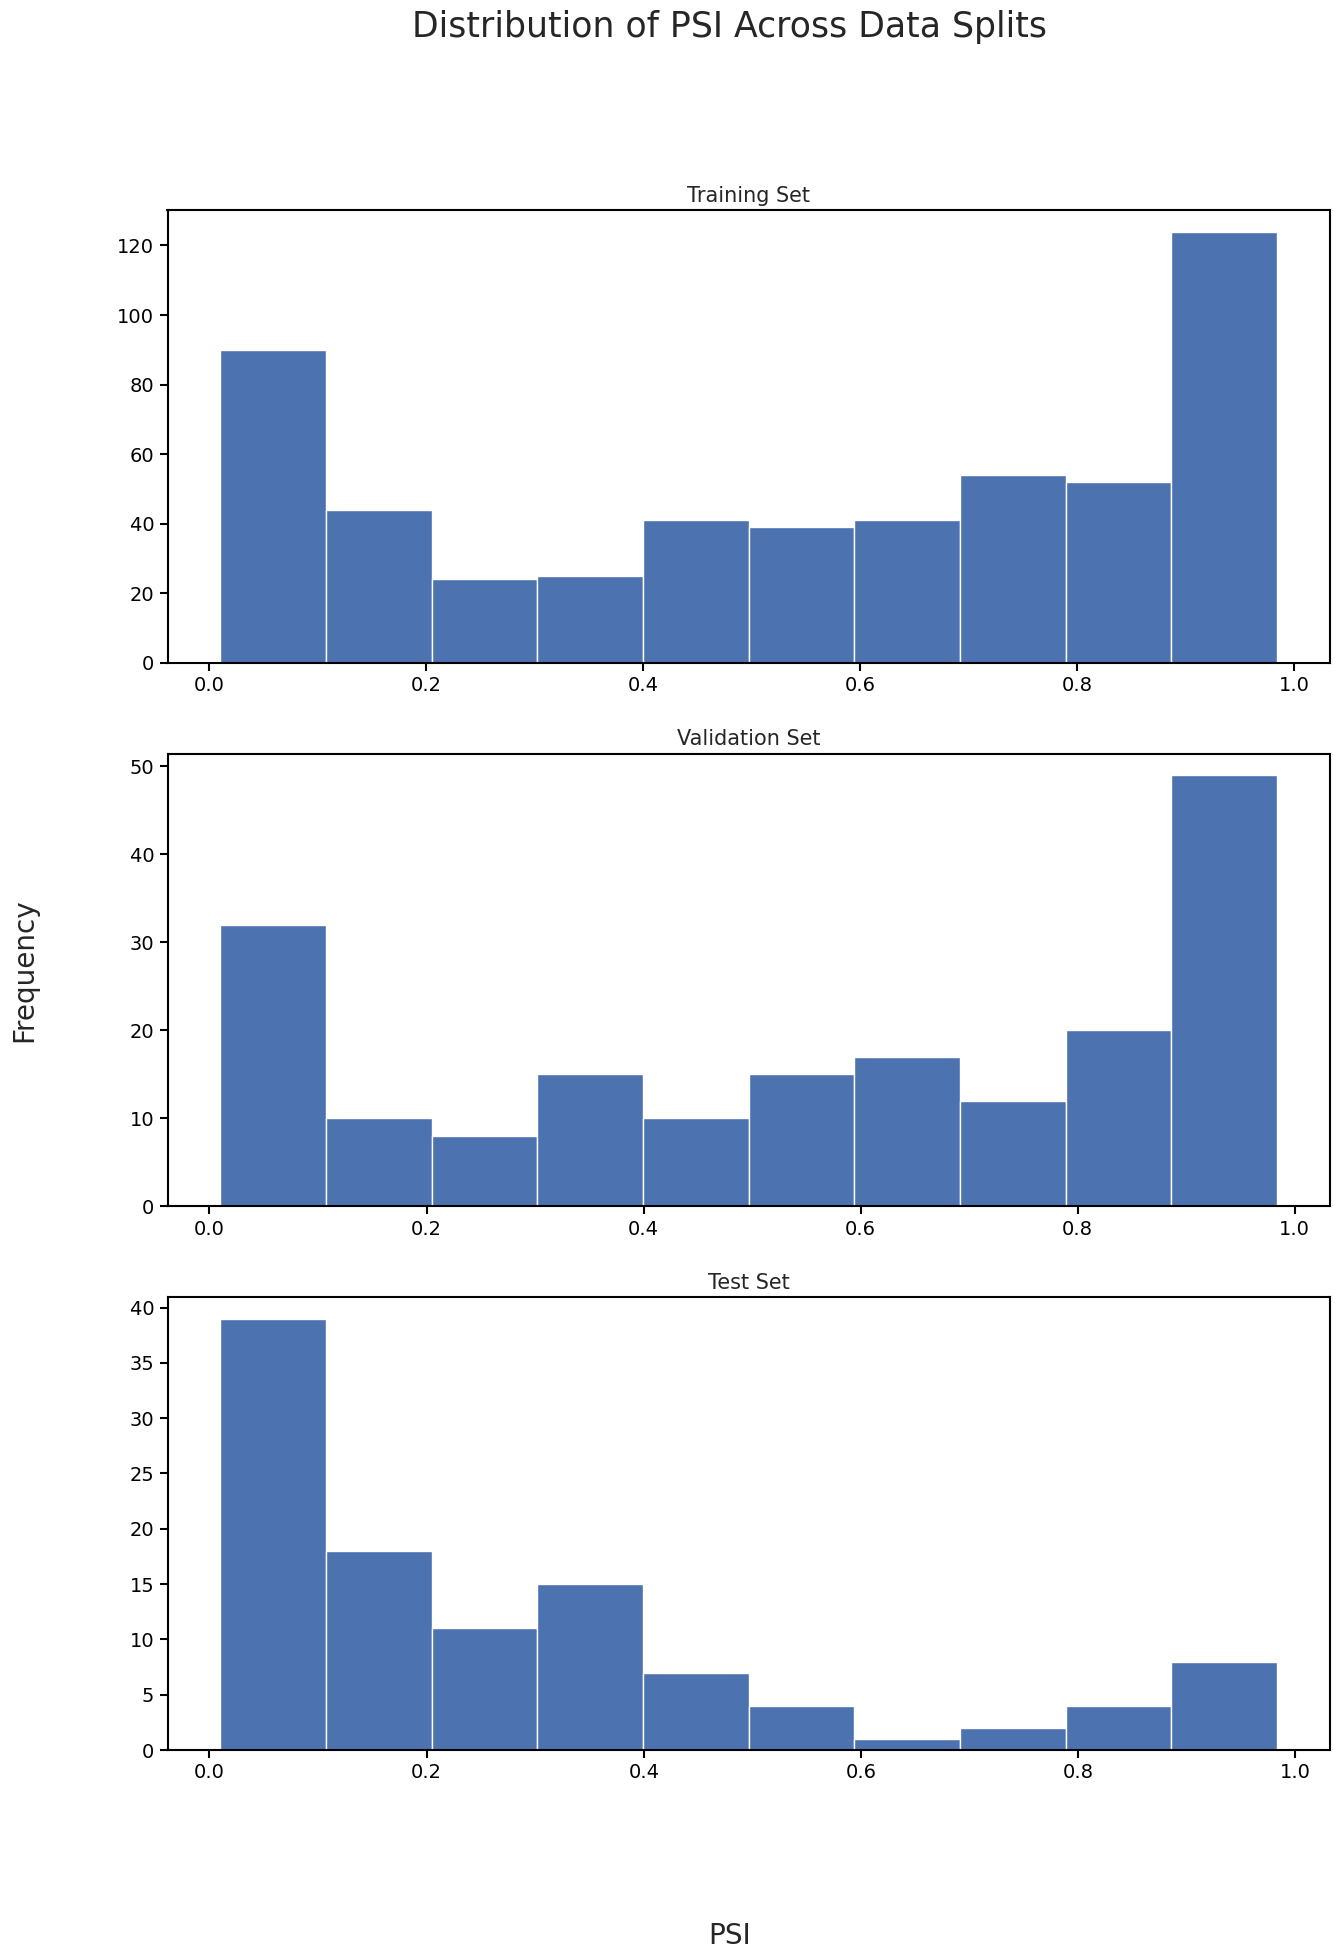

In [17]:
# PSI distributions of train, val and test
fig, ax = plt.subplots(3, figsize = (15, 20))
ax[0].hist([train[i][3] for i in range(len(train))])
ax[0].set_title("Training Set", fontsize = 15)
ax[1].hist([val[i][3] for i in range(len(val))])
ax[1].set_title("Validation Set", fontsize = 15)
ax[2].hist([test[i][3] for i in range(len(test))])
ax[2].set_title("Test Set", fontsize = 15)
fig.supxlabel("PSI", fontsize = 20)
fig.supylabel("Frequency", fontsize = 20)
fig.suptitle("Distribution of PSI Across Data Splits", fontsize = 25)


In [18]:
# Visualizing the splits
# Note that the train set is almost guaranteed to 
# have a higher total coverage than val and test since
# the total family size is 18 times greater

sizes = []
n_fams = []
tot_cov = []
mean_cov = []
mean_fam_cov = []
total_size = 0
for i in [train, val, test]:
    size = sum([j[0] for j in i])
    sizes.append(size)
    total_size += size
    n_fams.append(len(i))
    tot_cov.append(np.sum([j[1] for j in i]))
    mean_cov.append(np.sum([j[1] for j in i]) / np.sum([j[0] for j in i]))
    mean_fam_cov.append(np.mean([j[1] for j in i]))

percent_ = [round(size*100/total_size, 3) for size in sizes]


train_size = sum([i[0] for i in train])
val_size = sum([i[0] for i in val])
test_size = sum([i[0] for i in test])
total = train_size + val_size + test_size

splits_df = pd.DataFrame({"Size": sizes, "Percent":percent_, "Number of Families": n_fams, "Total Coverage":tot_cov,\
                         "Mean Sample Coverage":mean_cov, "Mean Family Coverage":mean_fam_cov})

splits_df.index = ["Train", "Val", "Test"]
splits_df

,Size,Percent,Number of Families,Total Coverage,Mean Sample Coverage,Mean Family Coverage
Train,63492,90.003,534,1.059243e+07,166.830888,19836.005087
Val,3526,4.998,188,7.853417e+05,222.728777,4177.349291
Test,3526,4.998,109,8.639496e+05,245.022580,7926.143272


### Generate Supertable to Find Reference Sequences for Variants

In [19]:
# Split sequences into groupings based on reference sequence, and notate which groups are only population variants (i.e. no ClinVar annotation in supertable.tsv)
ref_supertable_dict = {}  # supertable reference -> seq_tuple (exon, intron1, intron2)
ref_eventID_supertableRef_dict = {}  # supertable eventID -> supertable reference (reference seq reference num)
var_supertable_dict = defaultdict(list)  # supertable reference -> list of variants reference num

# First pass read through of supertable for all references
with open(supertable_file, "r") as f:
    f.readline()  # throw out header
    for line in f:
        var = line.split(",")
        curr_supertable_ref = str(int(var[0]) + 1)
        event_id = var[1]
        snp = var[8]
        exon = var[4]
        intron1 = var[5]
        intron2 = var[6]
        seq_tuple = (exon, intron1, intron2)
        # parse reference
        if snp == "none":
            ref_supertable_dict[curr_supertable_ref] = seq_tuple
            if event_id not in ref_eventID_supertableRef_dict:
                ref_eventID_supertableRef_dict[event_id] = curr_supertable_ref

# Second pass read through of supertable for all variants
variant_positions = {}  # supertable ref -> [var_index]
supertable_var_to_ref_dict = {}  # supertable var reference -> supertable reference
with open(supertable_file, "r") as f:
    f.readline()  # throw out header
    for line in f:
        var = line.split(",")
        curr_supertable_ref = str(int(var[0]) + 1)
        event_id = var[1]
        snp = var[8]
        exon = var[4]
        intron1 = var[5]
        intron2 = var[6]
        seq_tuple = (exon, intron1, intron2)
        fullseq_supertable = intron1 + exon + intron2
        # parse ref
        if snp != "none":
            curr_supertable_ref2 = ref_eventID_supertableRef_dict[event_id]
            ref_exon, ref_5p_intron, ref_3p_intron = ref_supertable_dict[curr_supertable_ref2]
            # Ignore annotated variants but subsequence is the same as ref
            if fullseq_supertable == ref_5p_intron + ref_exon + ref_3p_intron:
                continue
            # group variants by their reference number
            var_supertable_dict[curr_supertable_ref2].append(curr_supertable_ref)
            ref_supertable_dict[int(curr_supertable_ref)] = int(curr_supertable_ref2)


### One-hot encoding of Variants and References

In [20]:
"""
One-hot encode subsequences that are expected for each module.
To keep this step consistent with MMSplice's repo, using kipoiseq for encoding.
kipoiseq = https://github.com/kipoi/kipoiseq
It's right padding with N's to achieve the same length given a seq_vec.
"""
import kipoiseq.transforms.functional as F


"""
Taken from MMSplice.utils
"""
def encodeDNA(seq_vec):
    max_len = max(map(len, seq_vec))
    return np.array([
        F.one_hot(F.pad(seq, max_len, anchor="start"), neutral_value=0, neutral_alphabet=['N', '*'])
        for seq in seq_vec
    ])


# process the sequences as defined by MMSplice
def process_sequences(exon, intron1, intron2):
    acceptor_intron = (SMN2_intron6 + intron1)[-100:-6]
    acceptor = (SMN2_intron6 + intron1)[-50:] + exon[:3]
    donor = exon[-5:] + intron2[:13]
    donor_intron = (intron2 + SMN2_intron7)[6:100]
    return (acceptor_intron, acceptor, exon, donor, donor_intron)


# necessary to make columns into empty strings for assignment later
def prepare_seqs(x):
    x["acceptor_intron"] = [""] * len(x)
    x["acceptor"] = [""] * len(x)
    x["donor"] = [""] * len(x)
    x["donor_intron"] = [""] * len(x)
    return x


# run process_sequences on exon and introns to 
# get the appropriate donor and acceptors
def get_seqs(x):
    acceptor_intron, acceptor, exon, donor, donor_intron = process_sequences(x["exon"], x["intron1"], x["intron2"])
    x["acceptor_intron"] = acceptor_intron
    x["acceptor"] = acceptor
    x["exon"] = exon
    x["donor"] = donor
    x["donor_intron"] = donor_intron
    return 


def get_sequences_from_families(dataset, splice_vs_super_full, ref_eventID_supertableRef_dict, var_supertable_dict, ref_supertable_dict):
    # ref_eventID_supertableRef_dict : event_id ->  reference num
    # var_supertable_dict : reference num -> (exon, intron1, intron2)
    # var_supertable_dict : reference num -> list(variant nums)
    # dataset : list of families in the form (family_size, total_avg_coverage, event_id)
    grouped_df = splice_vs_super_full.groupby("event_id").groups
    seqs_df = splice_vs_super_full
    seqs_df = prepare_seqs(seqs_df)
    splice_types = ["acceptor_intron", "acceptor", "exon", "donor", "donor_intron"]
    seqs_df = seqs_df[["intron1", "intron2"] + splice_types]
    seqs_df.apply(get_seqs, axis = 1)
    outputs = ["Supertable_Mean_Delta_Logit_PSI", "MMSplice_Delta_Logit_PSI"]
    for i in outputs:
        seqs_df[i] = splice_vs_super_full[i]
    info_out = splice_types + outputs
    data_variants = {}
    logits_ = []
    mmsplice_predictions = []
    for i in splice_types:
        data_variants[i] = []
    data_refs = {}
    for i in splice_types:
        data_refs[i] = []
    indx = 0
    for data in dataset:
        event_id = data[2]
        ref_num  = ref_eventID_supertableRef_dict[event_id]
        variant_nums = grouped_df[event_id]
        variants_family_df = seqs_df.iloc[variant_nums][info_out]
        ref_seq = process_sequences(*ref_supertable_dict[ref_num])
        curr_ref_seq_by_type = {}
        for i in range(len(ref_seq)):
            curr_ref_seq_by_type[splice_types[i]] = ref_seq[i]
        # populate the data with the sequences
        for i in splice_types:
            data_variants[i] += variants_family_df[i].tolist()
            data_refs[i] += [curr_ref_seq_by_type[i]] * len(variant_nums)
        logits_ += variants_family_df["Supertable_Mean_Delta_Logit_PSI"].tolist()
        mmsplice_predictions += variants_family_df["MMSplice_Delta_Logit_PSI"].tolist()    
    return data_variants, data_refs, logits_, mmsplice_predictions 


# one hot encode all the sequence types in 
# each dataset using a dictionary to keep track of 
# the sequences
def one_hot_encode_all(train, val, test):
    # e.g. train = (train_variants, train_refs)
    datasets = ("train", "val", "test")
    ref_types = ("variant", "ref")
    seq_types = [i for i in train[0]]
    assert [i for i in train[0]] == [i for i in val[0]] == [i for i in test[0]]
    seqs_one_hot = {}
    dataset_key = {"train":train, "val":val, "test":test}
    ref_key = {"variant":0, "ref":1}
    for dataset in datasets:
        for i in range(len(ref_types)):
            for seq_type in seq_types:
                seqs_one_hot[f"{dataset}_{ref_types[i]}_{seq_type}"] = \
                        encodeDNA(dataset_key[dataset][i][seq_type])
    return seqs_one_hot


# Create the final input and output one hots for the model.
def get_one_hots_from_splits(train, val, test):
    # get all the variants and corresponding reference for each family,
    # repeating for each of test, val and train splits
    test_variants, test_refs, test_logits, test_predictions     = get_sequences_from_families(test,  splice_vs_super_full, ref_eventID_supertableRef_dict, var_supertable_dict, ref_supertable_dict)
    val_variants, val_refs, val_logits, val_predictions         = get_sequences_from_families(val,   splice_vs_super_full, ref_eventID_supertableRef_dict, var_supertable_dict, ref_supertable_dict)
    train_variants, train_refs, train_logits, train_predictions = get_sequences_from_families(train, splice_vs_super_full, ref_eventID_supertableRef_dict, var_supertable_dict, ref_supertable_dict)
    
    # one hot encode every sequence in all the datasets. This is an internal function
    # that uses positional arguments to put the correct sequences into the dictionary keys 
    # the idea is to run get_one_hots_from_splits directly from the train, val and test families
    seqs_one_hot = one_hot_encode_all((train_variants, train_refs), (val_variants, val_refs), (test_variants, test_refs))
    x_train = [
        seqs_one_hot["train_ref_acceptor_intron"],
        seqs_one_hot["train_ref_acceptor"],
        seqs_one_hot["train_ref_exon"],
        seqs_one_hot["train_ref_donor"],
        seqs_one_hot["train_ref_donor_intron"],
        seqs_one_hot["train_variant_acceptor_intron"],
        seqs_one_hot["train_variant_acceptor"],
        seqs_one_hot["train_variant_exon"],
        seqs_one_hot["train_variant_donor"],
        seqs_one_hot["train_variant_donor_intron"],
    ]
    x_val = [
        seqs_one_hot["val_ref_acceptor_intron"],
        seqs_one_hot["val_ref_acceptor"],
        seqs_one_hot["val_ref_exon"],
        seqs_one_hot["val_ref_donor"],
        seqs_one_hot["val_ref_donor_intron"],
        seqs_one_hot["val_variant_acceptor_intron"],
        seqs_one_hot["val_variant_acceptor"],
        seqs_one_hot["val_variant_exon"],
        seqs_one_hot["val_variant_donor"],
        seqs_one_hot["val_variant_donor_intron"],
    ]
    x_test = [
        seqs_one_hot["test_ref_acceptor_intron"],
        seqs_one_hot["test_ref_acceptor"],
        seqs_one_hot["test_ref_exon"],
        seqs_one_hot["test_ref_donor"],
        seqs_one_hot["test_ref_donor_intron"],
        seqs_one_hot["test_variant_acceptor_intron"],
        seqs_one_hot["test_variant_acceptor"],
        seqs_one_hot["test_variant_exon"],
        seqs_one_hot["test_variant_donor"],
        seqs_one_hot["test_variant_donor_intron"],
    ]
    y_train = [
        train_logits
    ]
    y_val = [
        val_logits
    ]
    y_test = [
        test_logits
    ]
    y_predicts_train = [
        train_predictions
    ]
    y_predicts_val = [
        val_predictions
    ]
    y_predicts_test = [
        test_predictions
    ]
    return x_train, x_val, x_test, y_train, y_val, y_test, y_predicts_train, y_predicts_val, y_predicts_test
   
    
# process the outputs into the correct shape for 
# the model
def process_y(y):
    y = np.array(y)
    y = y.T
    return y
    
    

In [21]:
# execute function to get the final one hot data
x_train, x_val, x_test, y_train, y_val, y_test, y_predicts_train, y_predicts_val, y_predicts_test = get_one_hots_from_splits(train,val,test)
y_train = process_y(y_train)
y_val = process_y(y_val)
y_test = process_y(y_test)
y_predicts_train = process_y(y_predicts_train)
y_predicts_val = process_y(y_predicts_val)
y_predicts_test = process_y(y_predicts_test)

/storage/yu/home/u259871/.conda/envs/tensorflow_2.4/lib/python3.7/site-packages/ipykernel_launcher.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


### Dump Data into Pickle

In [22]:
os.getcwd()

'/storage/yu/Projects/P000--ESL_continuation/GitHub/P000--Exon_Skipping_Library'

In [23]:
output_models_dir = create_directory(os.path.join(os.getcwd(), "models/"))
output_figures_dir = create_directory(os.path.join(output_models_dir + "figures/"))
data_dir = os.path.join(output_models_dir, "data", "mmsplice7/")
data_dir = create_directory(data_dir)

In [24]:
pickle.dump(x_train, open(data_dir + "x_train.p", "wb"))
pickle.dump(x_val, open(data_dir + "x_val.p", "wb"))
pickle.dump(x_test, open(data_dir + "x_test.p", "wb"))
pickle.dump(y_train, open(data_dir + "y_train.p", "wb"))
pickle.dump(y_val, open(data_dir + "y_val.p", "wb"))
pickle.dump(y_test, open(data_dir + "y_test.p", "wb"))
pickle.dump(y_predicts_train, open(data_dir + "y_predicts_train.p", "wb"))
pickle.dump(y_predicts_val, open(data_dir + "y_predicts_val.p", "wb"))
pickle.dump(y_predicts_test, open(data_dir + "y_predicts_test.p", "wb"))

### Load Data from Pickle

In [25]:
data_names = ["x_train.p", "x_val.p", "x_test.p", "y_train.p", \
                  "y_val.p", "y_test.p", "y_predicts_train.p", "y_predicts_val.p", "y_predicts_test.p"]
def get_loaded_pickle(data_dir):
    dict_ = {}
    if not os.path.exists(os.path.join(data_dir, "x_train.p")):
        raise FileNotFoundError(os.path.join(data_dir, "x_train.p"))
        return False, {}
    else:
        for name in data_names:
            path = os.path.join(data_dir, name)
            if os.path.exists(path):
                with open(path, "rb") as f:
                    dict_[name.split(".")[0]] = pickle.load(f)
            else:
                print("path", path, "does not exist")
    return True, dict_


In [26]:
# Redefine directories to make starting from this point easier
output_models_dir = create_directory(os.path.join(os.getcwd(), "models/"))
output_figures_dir = create_directory(os.path.join(output_models_dir + "figures/"))
data_dir = os.path.join(output_models_dir, "data", "mmsplice7/")
data_dir = create_directory(data_dir)

loaded, dict_data = get_loaded_pickle(data_dir)
if loaded:
    data = dict_data
    x_train = data["x_train"]
    x_val = data["x_val"]
    x_test = data["x_test"]
    y_train = data["y_train"]
    y_val = data["y_val"]
    y_test = data["y_test"]
    y_predicts_train = data["y_predicts_train"]
    y_predicts_val = data["y_predicts_val"]
    y_predicts_test = data["y_predicts_test"]
    
    

### Train Model

#### Hyperparameter Tuning with Hyperband


In [27]:
def reinitialize_model(model):
    for i in model._layers:
        if "input" in i.name:
            continue
        if len(i.weights) > 0:
            w = merged_MMSplice_full.get_layer(i.name).get_weights()
            wz = [np.random.normal(size=(wi.shape)) for wi in w]
            merged_MMSplice_full.get_layer(i.name).set_weights(wz)
            
            
def add_regularization_L1(model, val = 0.01):
    for i in model._layers:
        if "input" in i.name:
            continue
        if len(i.weights) > 0:
            merged_MMSplice_full.get_layer(i.name).kernel_regularizer = regularizers.L1(val)
            
            
def add_regularization_L2(model, val = 0.01):
    for i in model._layers:
        if "input" in i.name:
            continue
        if len(i.weights) > 0:
            merged_MMSplice_full.get_layer(i.name).kernel_regularizer = regularizers.L2(val)
            
            
def add_regularization_elastic(model, val1 = 0.01, val2 = 0.01):
    for i in model._layers:
        if "input" in i.name:
            continue
        if len(i.weights) > 0:
            merged_MMSplice_full.get_layer(i.name).kernel_regularizer = regularizers.l1_l2(l1=val1, l2=val2)
            

def get_aggregate_data(x_train, x_val, x_test):
    x_full = [None] * len(x_train)
    for i in range(len(x_train)):
        x_full[i] = np.concatenate([x_train[i], x_val[i], x_test[i]], axis = 0)
    return x_full



In [28]:
def hyperband_mmsplice(hp):
    # Reload the pre-trained model for fine-tuning with 
    # new hyperparameters
    for i in merged_MMSplice_full.layers:
        if isinstance(i, Functional):
            for layer in i.layers:
                if len(layer.weights) > 0:
                    layer.set_weights(mm_splice_saved.get_layer(i.name).get_layer(layer.name).get_weights())
                    hp_l1 = hp.Float("l1_" + layer.name, min_value = 0.0, max_value = 0.01, step = 0.001)
                    hp_l2 = hp.Float("l2_" + layer.name, min_value = 0.0, max_value = 0.01, step = 0.001)
                    layer.kernel_regularizer = regularizers.l1_l2(l1=hp_l1, l2=hp_l2)
                if "dropout" in layer.name:
                    hp_drop = hp.Float("drop_rate_" + layer.name, min_value = 0.1, max_value = 0.4, step = 0.05)
                    layer.rate = hp_drop
    hp_lr = hp.Float('learning_rate', min_value=1e-7, max_value=1e-5, step=((1e-5-1e-7)/10))
    # use epsilon = 1e-07 due to numerical stability issues
    adam = Adam(lr=hp_lr, beta_1=0.9, beta_2=0.999, epsilon=1e-07)
    # MSE seems to perform better with the new dataset
    merged_MMSplice_full.compile(loss="mse", optimizer=adam)
    return merged_MMSplice_full
    

In [29]:
tuner = kerastuner.Hyperband(hyperband_mmsplice,
                     objective='val_loss',
                     max_epochs=20,
                     factor=3,
                     directory=output_models_dir + "hyperparam26")

tuner.search_space_summary()

INFO:tensorflow:Reloading Tuner from /storage/yu/Projects/P000--ESL_continuation/GitHub/P000--Exon_Skipping_Library/models/hyperparam26/untitled_project/tuner0.json
Search space summary
Default search space size: 38
l1_convSpliceSite_acceptor_ref (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.01, 'step': 0.001, 'sampling': 'linear'}
l2_convSpliceSite_acceptor_ref (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.01, 'step': 0.001, 'sampling': 'linear'}
l1_batch_normalization_1_acceptor_ref (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.01, 'step': 0.001, 'sampling': 'linear'}
l2_batch_normalization_1_acceptor_ref (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.01, 'step': 0.001, 'sampling': 'linear'}
l1_conv1by1_acceptor_ref (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.01, 'step': 0.001, 'sampling': 'linear'}
l2_conv1by1_acceptor_ref (Float)
{'d

In [30]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta = 0.001, patience=5)

In [31]:
tuner.search(x_train, y_train, epochs=15, \
             validation_data=(x_val, y_val), \
            callbacks=[stop_early])
# output: from re-run: "INFO:tensorflow:Oracle triggered exit"
#         initial run: "Trial 30 Complete [<trial_30_hours>h <trial_30_minutes>m <trial_30_seconds>s]
#                       val_loss: <trial_30_val_loss>
#                       Best val_loss So Far: <best_val_loss>
#                       Total elapsed time: <hours>h <minutes>m <seconds>s
#                       INFO:tensorflow:Oracle triggered exit"

INFO:tensorflow:Oracle triggered exit


In [32]:
# Get the optimal hyperparameters
best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]
for value in best_hps.values:
    print(value, best_hps.get(value))

l1_convSpliceSite_acceptor_ref 0.001
l2_convSpliceSite_acceptor_ref 0.009000000000000001
l1_batch_normalization_1_acceptor_ref 0.001
l2_batch_normalization_1_acceptor_ref 0.005
l1_conv1by1_acceptor_ref 0.005
l2_conv1by1_acceptor_ref 0.006
l1_batch_normalization_2_acceptor_ref 0.007
l2_batch_normalization_2_acceptor_ref 0.009000000000000001
drop_rate_dropout_1_acceptor_ref 0.15000000000000002
l1_denseSS_acceptor_ref 0.0
l2_denseSS_acceptor_ref 0.005
l1_dense1_donor_ref 0.009000000000000001
l2_dense1_donor_ref 0.01
l1_batch_normalization_1_donor_ref 0.0
l2_batch_normalization_1_donor_ref 0.01
drop_rate_dropout_1_donor_ref 0.15000000000000002
l1_dense2_donor_ref 0.004
l2_dense2_donor_ref 0.0
l1_batch_normalization_2_donor_ref 0.003
l2_batch_normalization_2_donor_ref 0.007
drop_rate_dropout_2_donor_ref 0.30000000000000004
l1_dense_1_donor_ref 0.006
l2_dense_1_donor_ref 0.007
l1_conv_acceptor_intron_ref 0.007
l2_conv_acceptor_intron_ref 0.0
l1_dense3_acceptor_intron_ref 0.006
l2_dense3_acce

In [33]:
# Build the model with the optimal hyperparameters and train until it overfits then revert to best validation set epoch
model = tuner.hypermodel.build(best_hps)
#monitor to restore best epoch 
stop_early_save_best = tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta = 0.001, patience=20, restore_best_weights=True)
history = model.fit(x_train, y_train, epochs=50, validation_data=(x_val, y_val), callbacks = [stop_early_save_best])

val_acc_per_epoch = history.history['val_loss']
best_epoch = val_acc_per_epoch.index(min(val_acc_per_epoch)) + 1
print('Best epoch: %d' % (best_epoch,), min(val_acc_per_epoch))

2025-09-08 09:56:19.548277: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)
2025-09-08 09:56:19.549063: I tensorflow/core/platform/profile_utils/cpu_utils.cc:112] CPU Frequency: 2300000000 Hz


Epoch 1/50


2025-09-08 09:56:23.142326: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcublas.so.10
2025-09-08 09:56:23.438762: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudnn.so.7
2025-09-08 09:56:24.903888: W tensorflow/stream_executor/gpu/asm_compiler.cc:63] Running ptxas --version returned 256
2025-09-08 09:56:25.081546: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] Internal: ptxas exited with non-zero error code 256, output: 
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.


1985/1985 [==============================] - 71s 26ms/step - loss: 2.8226 - val_loss: 1.2931
Epoch 2/50
1985/1985 [==============================] - 21s 10ms/step - loss: 2.5390 - val_loss: 1.2631
Epoch 3/50
1985/1985 [==============================] - 21s 10ms/step - loss: 2.3346 - val_loss: 1.2428
Epoch 4/50
1985/1985 [==============================] - 20s 10ms/step - loss: 2.2354 - val_loss: 1.2317
Epoch 5/50
1985/1985 [==============================] - 20s 10ms/step - loss: 2.1036 - val_loss: 1.2218
Epoch 6/50
1985/1985 [==============================] - 20s 10ms/step - loss: 1.9894 - val_loss: 1.2164
Epoch 7/50
1985/1985 [==============================] - 20s 10ms/step - loss: 1.9613 - val_loss: 1.2155
Epoch 8/50
1985/1985 [==============================] - 20s 10ms/step - loss: 1.8693 - val_loss: 1.2141
Epoch 9/50
1985/1985 [==============================] - 21s 10ms/step - loss: 1.8568 - val_loss: 1.2119
Epoch 10/50
1985/1985 [==============================] - 20s 10ms/step - lo

### Save Model

The hyperparameter tuning run is called MMSplice_delta_logit_PSI_model_retrained10.hdf5



In [34]:
"""
Save reimplemented MMSplice model
"""

model.save(output_models_dir + "/MMSplice_delta_logit_PSI_model_retrained10.hdf5")


### Evaluate Model

In [35]:
merged_MMSplice_full.load_weights(output_models_dir + "/MMSplice_delta_logit_PSI_model_retrained10.hdf5")

In [36]:
def get_r2_from_model(mmsplice_model, x, y):
    predictions = mmsplice_model.predict(x)
    scores = []
    pred = predictions[:,0]
    obs = y[:,0]
    slope, intercept, r_value, p_value, std_err = stats.linregress(obs,pred)
    scores.append(round(r_value**2, 3))
    mean = round(np.array(scores).sum(),3)
    return mean


def merge_train_val_test(train, val, test, y_train, y_val, y_test):
    merged_X = [None] * len(train)
    for i in range(len(train)):
        merged_X[i] = np.concatenate([train[i], val[i], test[i]])
    merged_Y = np.concatenate([y_train, y_val, y_test])    
    return merged_X, merged_Y



In [37]:
# Note: The validation loss can be different from the run during hyperparameter tuning.
# This is likely due to randomness during training (e.g. using dropout)

In [38]:
print("retrained model train r2".ljust(26), get_r2_from_model(merged_MMSplice_full, x_train, (y_train)))
print("retrained model val r2".ljust(26), get_r2_from_model(merged_MMSplice_full, x_val, (y_val)))
print("retrained model test r2".ljust(26), get_r2_from_model(merged_MMSplice_full, x_test, (y_test)))

retrained model train r2   0.605
retrained model val r2     0.483
retrained model test r2    0.478


In [39]:
X,Y = merge_train_val_test(x_train, x_val, x_test, y_train, y_val, y_test)
print("retrained model aggregate data r2", get_r2_from_model(merged_MMSplice_full, X, Y))

retrained model aggregate data r2 0.593


In [40]:
print("baseline train".ljust(15), r2(y_predicts_train[:,0], y_train[:,0]))
print("baseline val".ljust(15), r2(y_predicts_val[:,0], y_val[:,0]))
print("baseline test".ljust(15), r2(y_predicts_test[:,0], y_test[:,0]))

baseline train  0.43360681760057646
baseline val    0.4565423917881343
baseline test   0.43925457285954356


In [41]:
Y_baseline = np.concatenate([y_predicts_train, y_predicts_val, y_predicts_test], axis = 0)
print("baseline model aggregate data r2", r2(Y_baseline[:,0], Y[:,0]))

baseline model aggregate data r2 0.43329490430597395


### Plotting

In [42]:
x_preds_train = model.predict(x_train)
x_preds_val   = model.predict(x_val) 
x_preds_test  = model.predict(x_test)

In [43]:
r_train = calc_r(x_preds_train[:,0], y_train[:,0])
r_val = calc_r(x_preds_val[:,0], y_val[:,0])
r_test = calc_r(x_preds_test[:,0], y_test[:,0])

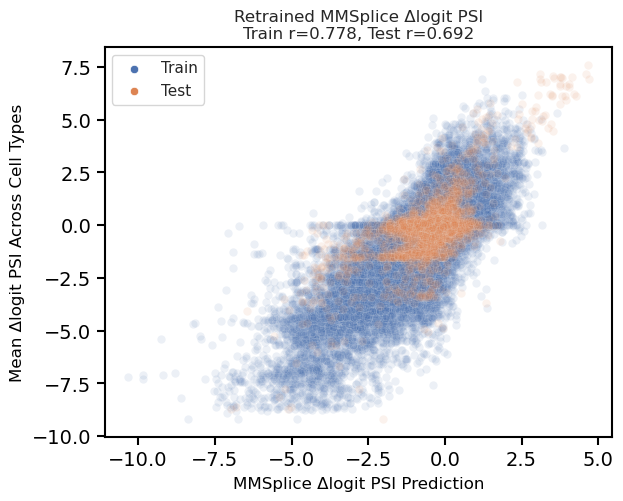

delta logit PSI correlation, test =  0.691560882524886
delta logit PSI correlation, train =  0.7775767611766945


In [44]:
sns.scatterplot(x=x_preds_train[:,0], y=y_train[:,0], alpha =0.1)
#plt.title('Training set')
#plt.show()

sns.scatterplot(x=x_preds_test[:,0], y=y_test[:,0], alpha =0.1)
plt.xlabel('MMSplice Δlogit PSI Prediction')
plt.ylabel('Mean Δlogit PSI Across Cell Types')
#plt.title('Test set')
plt.tight_layout()
plt.title(f"Retrained MMSplice Δlogit PSI\nTrain r={round(r_train,3)}, Test r={round(r_test,3)}")
leg = plt.legend(["Train", "Test"])
for lh in leg.legendHandles: 
    lh.set_alpha(1)
plt.savefig(output_figures_dir + "prediction_observation_scatter10.png")
plt.savefig(output_figures_dir + "prediction_observation_scatter10.pdf")
plt.show()

print("delta logit PSI correlation, test = ", r_test)
print("delta logit PSI correlation, train = ", r_train)

#### Compare to predictions

In [45]:
r_train_baseline = calc_r(y_predicts_train[:,0], y_train[:,0])
r_val_baseline = calc_r(y_predicts_val[:,0], y_val[:,0])
r_test_baseline = calc_r(y_predicts_test[:,0], y_test[:,0])

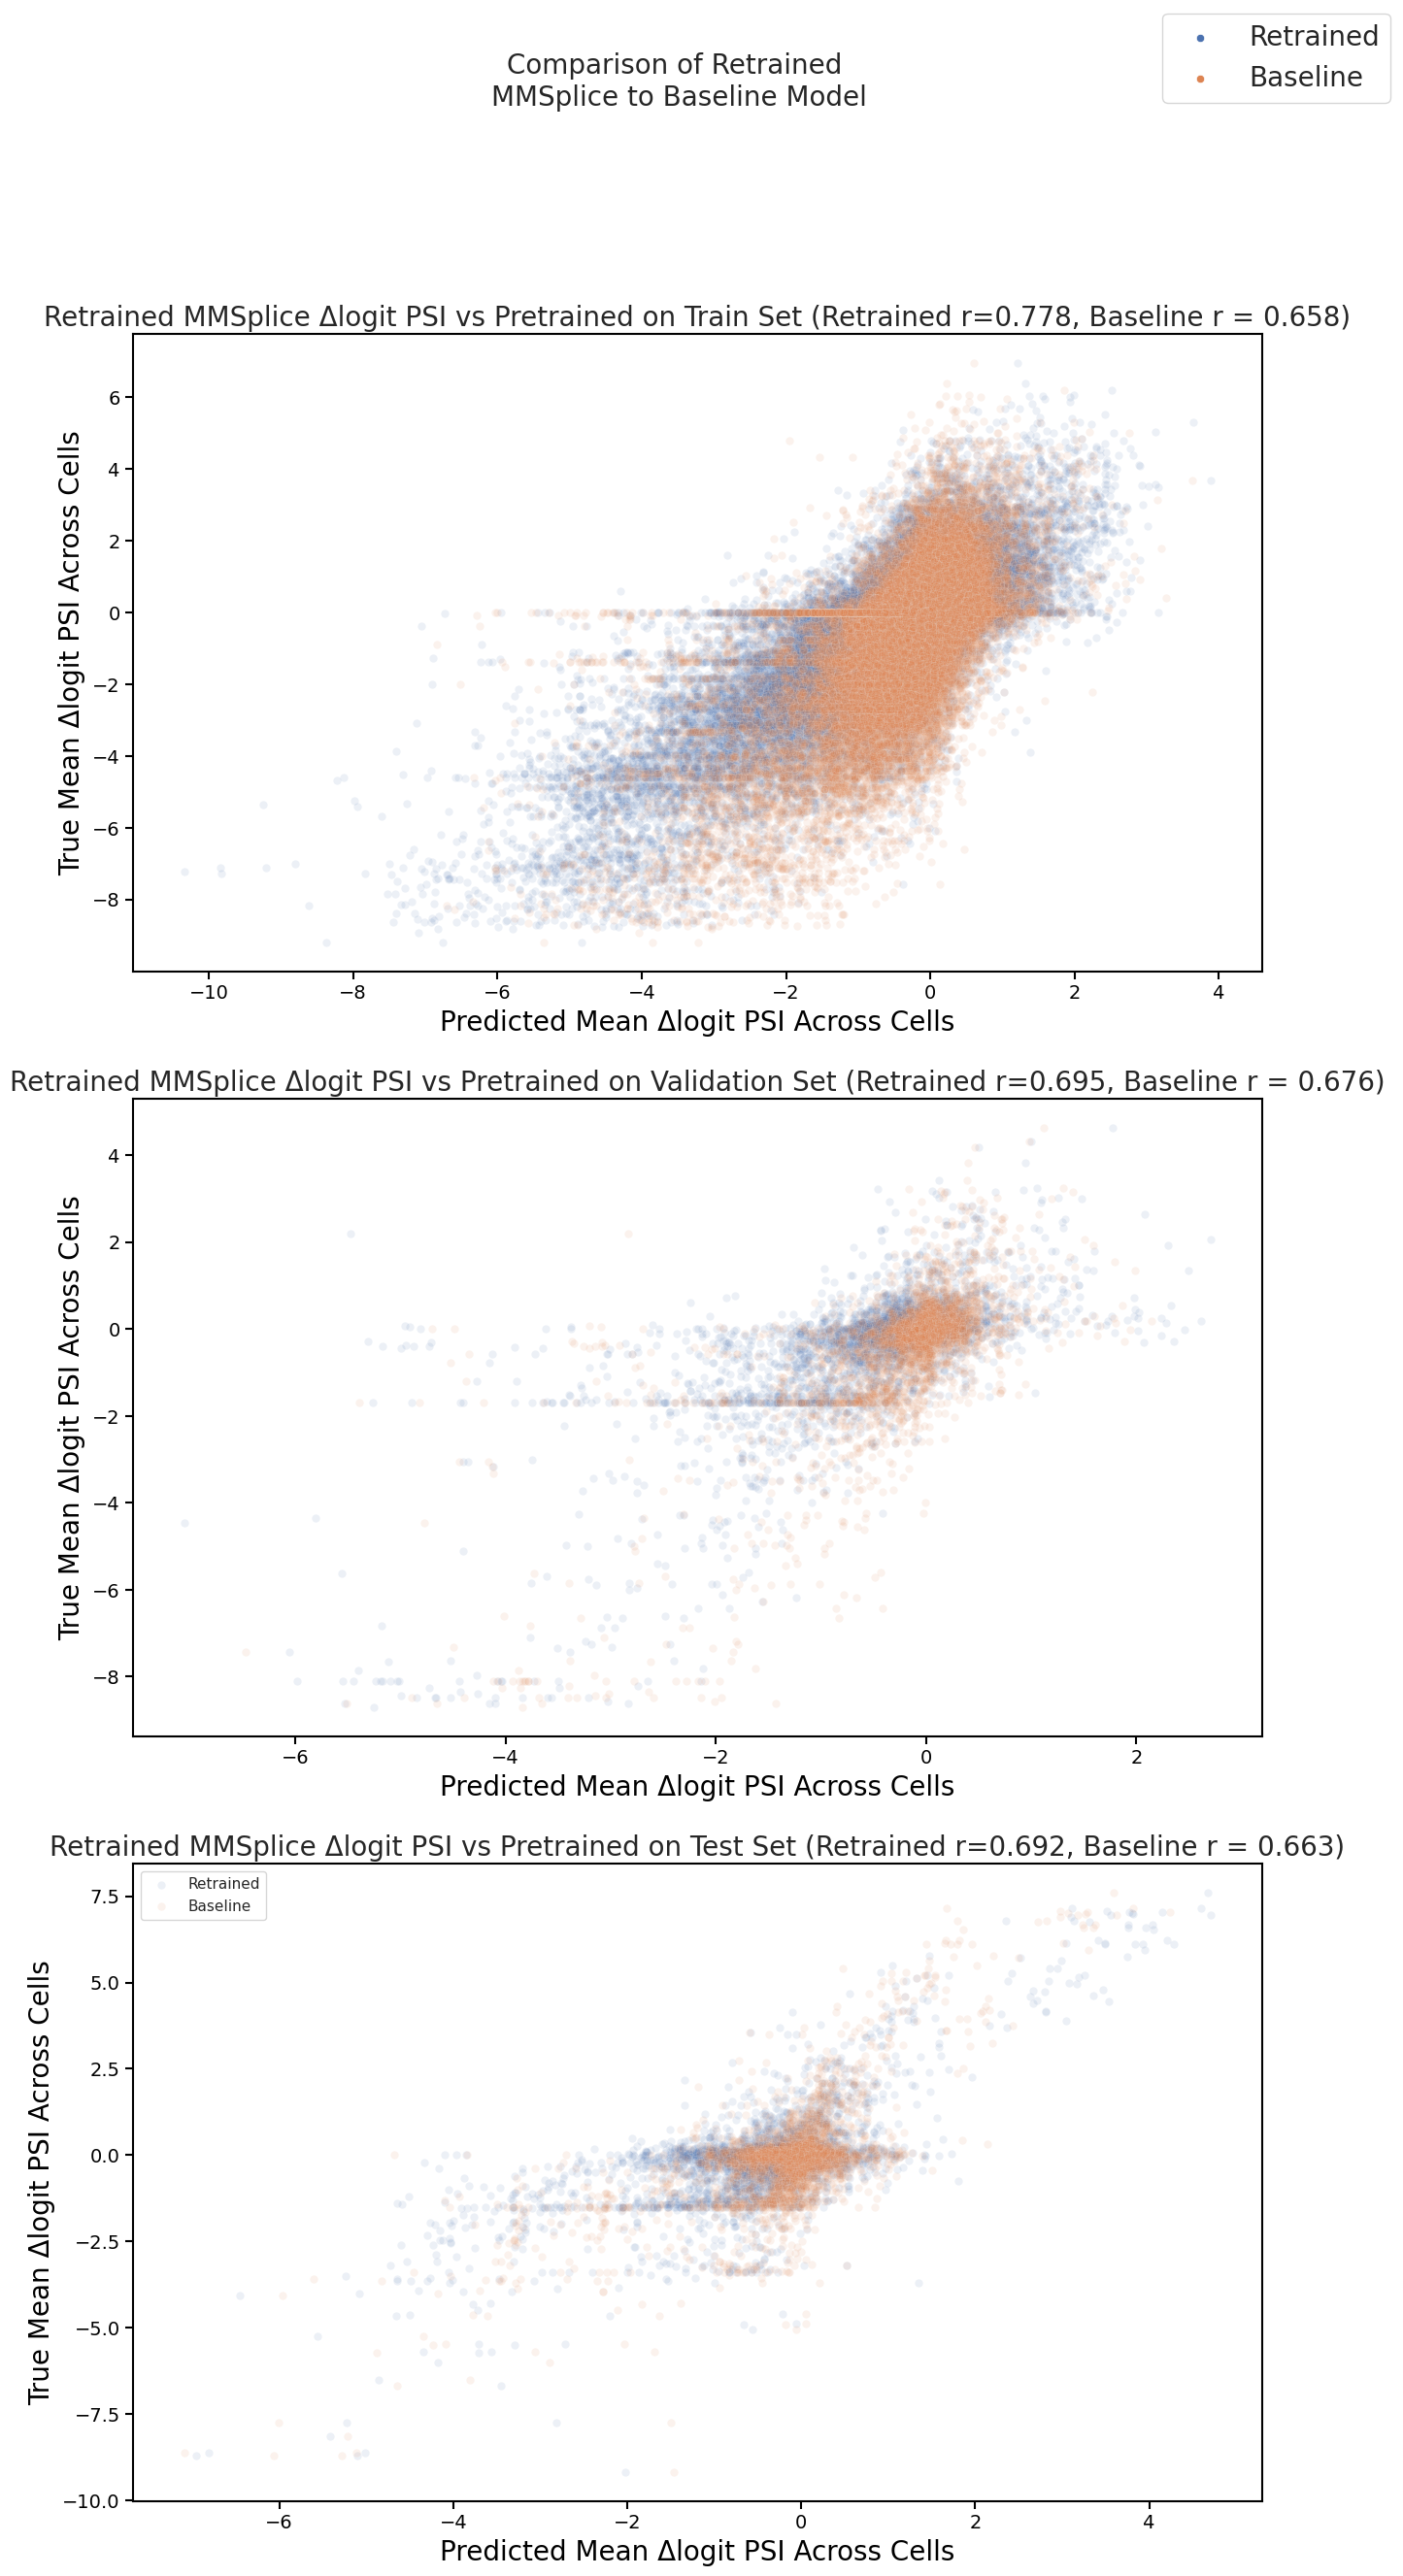

In [46]:
fig, ax = plt.subplots(3, figsize = (15,29))

slope, intercept, r_base, p_value, std_err = stats.linregress(y_test[:,0],y_predicts_test[:,0])

sns.scatterplot(x=x_preds_train[:,0], y=y_train[:,0], alpha =0.1, ax=ax[0])
sns.scatterplot(x=y_predicts_train[:,0], y=y_train[:,0], alpha =0.1, ax=ax[0])


sns.scatterplot(x=x_preds_val[:,0], y=y_val[:,0], alpha =0.1, ax=ax[1])
sns.scatterplot(x=y_predicts_val[:,0], y=y_val[:,0], alpha =0.1, ax=ax[1])

sns.scatterplot(x=x_preds_test[:,0], y=y_test[:,0], alpha =0.1, ax=ax[2], label = "Retrained")
sns.scatterplot(x=y_predicts_test[:,0], y=y_test[:,0], alpha =0.1, ax=ax[2], label = "Baseline")

data_names = ["Train", "Validation", "Test"]
r_vals = [(r_train, r_train_baseline), (r_val, r_val_baseline), (r_test, r_test_baseline)]
for i in range(3):
    ax[i].set_title(f"Retrained MMSplice Δlogit PSI vs Pretrained on {data_names[i]} Set (Retrained r={round(r_vals[i][0],3)}, Baseline r = {round(r_vals[i][1],3)})", fontsize=20)
    ax[i].set_xlabel("Predicted Mean Δlogit PSI Across Cells", fontsize=20)
    ax[i].set_ylabel("True Mean Δlogit PSI Across Cells", fontsize=20)
# fig.legend(fontsize=20)
leg = fig.legend(fontsize=20, loc = "upper right")
for lh in leg.legendHandles: 
    lh.set_alpha(1)
fig.suptitle("Comparison of Retrained \nMMSplice to Baseline Model", fontsize=20)
plt.savefig(output_figures_dir + "mmsplice_vs_pretrained10.png")
plt.savefig(output_figures_dir + "mmsplice_vs_pretrained10.pdf")

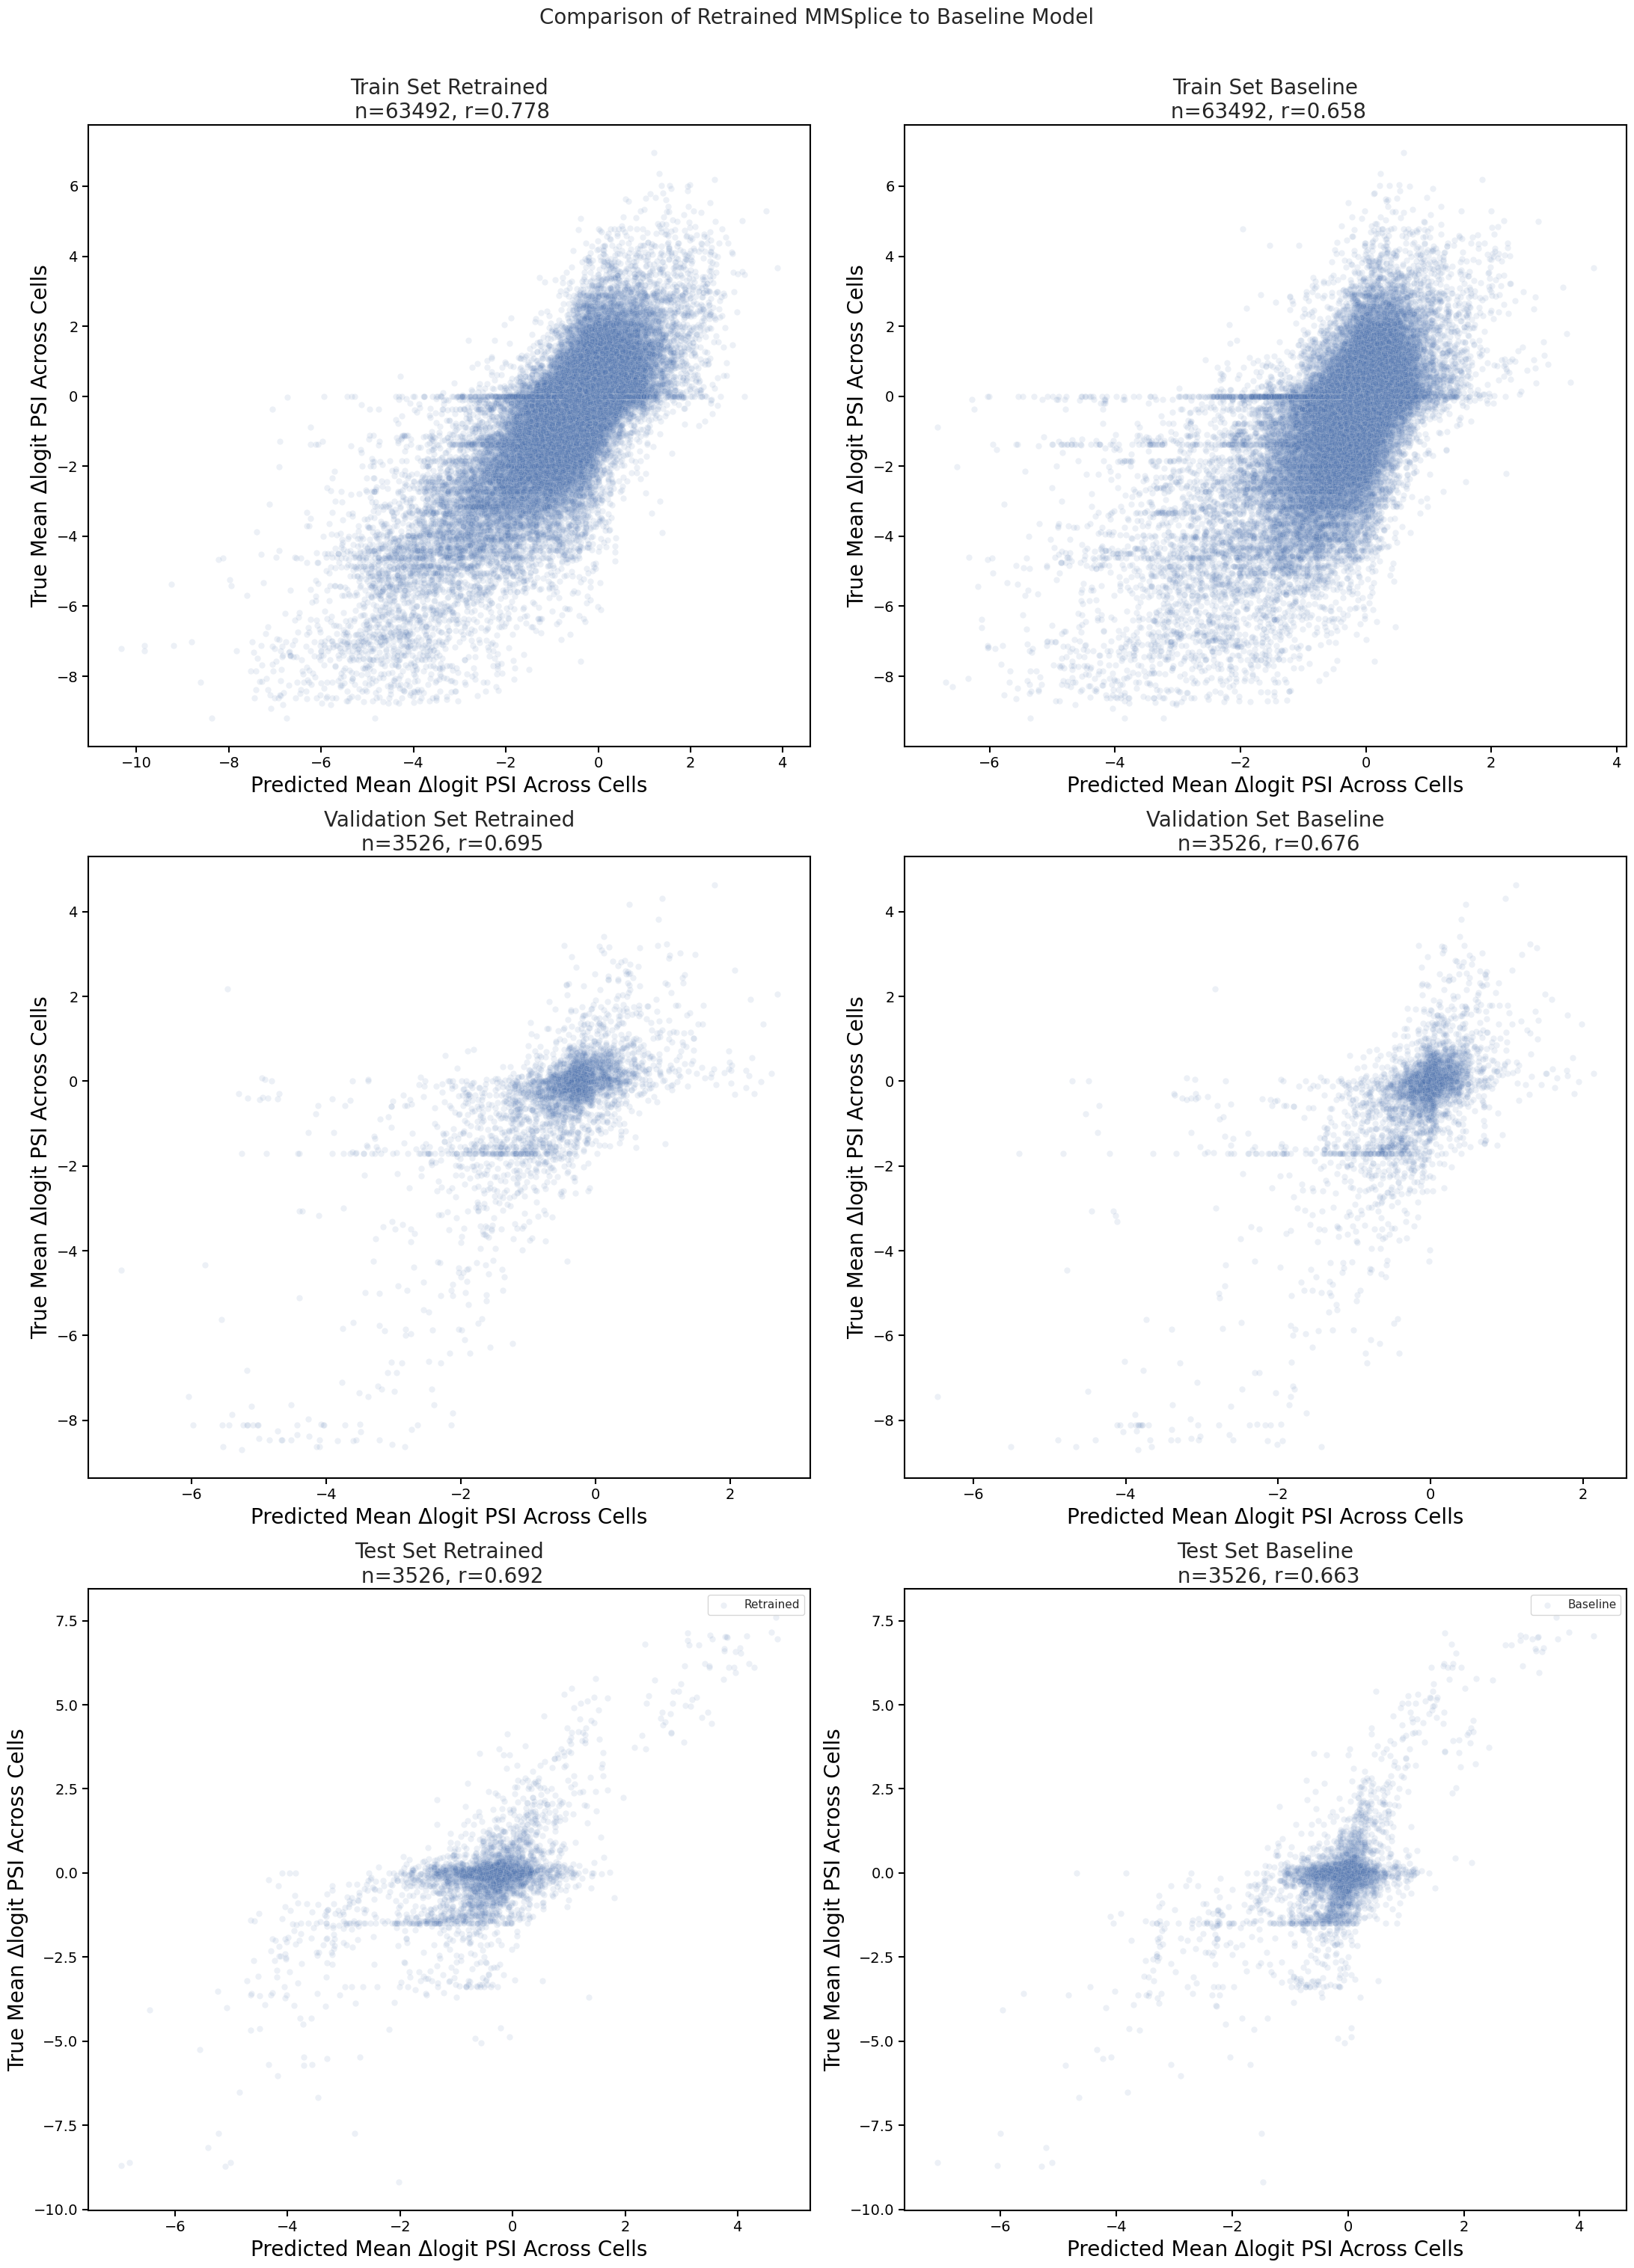

In [47]:
fig, ax = plt.subplots(3, 2, figsize = (22, 30))

slope, intercept, r_base, p_value, std_err = stats.linregress(y_test[:,0],y_predicts_test[:,0])

sns.scatterplot(x=x_preds_train[:,0], y=y_train[:,0], alpha =0.1, ax=ax[0][0])
sns.scatterplot(x=y_predicts_train[:,0], y=y_train[:,0], alpha =0.1, ax=ax[0][1])


sns.scatterplot(x=x_preds_val[:,0], y=y_val[:,0], alpha =0.1, ax=ax[1][0])
sns.scatterplot(x=y_predicts_val[:,0], y=y_val[:,0], alpha =0.1, ax=ax[1][1])

sns.scatterplot(x=x_preds_test[:,0], y=y_test[:,0], alpha =0.1, ax=ax[2][0], label = "Retrained")
sns.scatterplot(x=y_predicts_test[:,0], y=y_test[:,0], alpha =0.1, ax=ax[2][1], label = "Baseline")

data = [(x_preds_train, y_predicts_train), (x_preds_val, y_predicts_val), (x_preds_test, y_predicts_test)]
data_names = ["Train", "Validation", "Test"]
model_names = ["Retrained", "Baseline"]
r_vals = [(r_train, r_train_baseline), (r_val, r_val_baseline), (r_test, r_test_baseline)]
for i in range(3):
    for j in range(2):
        ax[i][j].set_title(f"{data_names[i]} Set {model_names[j]}\n n={len(data[i][j])}, r={round(r_vals[i][j],3)}", fontsize=20)
        ax[i][j].set_xlabel("Predicted Mean Δlogit PSI Across Cells", fontsize=20)
        ax[i][j].set_ylabel("True Mean Δlogit PSI Across Cells", fontsize=20)
# fig.legend(fontsize=20
for lh in leg.legendHandles: 
    lh.set_alpha(1)
fig.suptitle("Comparison of Retrained MMSplice to Baseline Model", fontsize=20, x = 0.5, y = 1.01)
fig.tight_layout()
plt.savefig(output_figures_dir + "mmsplice_vs_pretrained_split10.png")
plt.savefig(output_figures_dir + "mmsplice_vs_pretrained_split10.pdf")

In [48]:
preds = merged_MMSplice_full.predict(X)

In [49]:
preds.shape

(70544, 1)

### Aggregate Data Plots

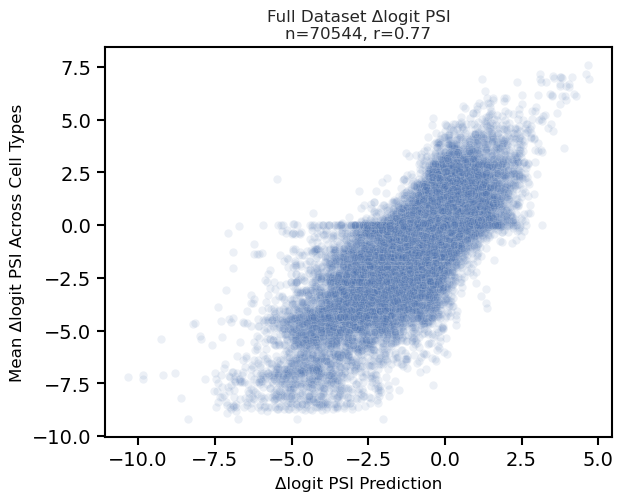

delta logit PSI correlation=  0.7698212985554141
delta logit PSI R^2=  0.592624831709544


In [50]:
preds = model.predict(X)
true = np.concatenate([y_train, y_val, y_test], axis = 0)
r_val = calc_r(preds[:,0], true[:,0])
sns.scatterplot(x=preds[:,0], y=true[:,0], alpha =0.1)
plt.xlabel('Δlogit PSI Prediction')
plt.ylabel('Mean Δlogit PSI Across Cell Types')
plt.tight_layout()
plt.title(f"Full Dataset Δlogit PSI\nn={len(true)}, r={round(r_val, 3)}")
plt.savefig(output_figures_dir + "retrained_predictions_scatter_full_data10.png")
plt.savefig(output_figures_dir + "retrained_predictions_scatter_full_data10.pdf")
plt.show()



print("delta logit PSI correlation= ", r_val)
print("delta logit PSI R^2= ", r_val ** 2)

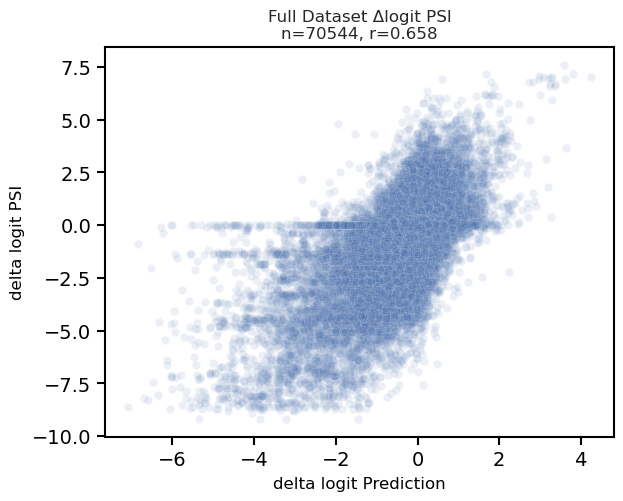

delta logit PSI correlation=  0.6582513990155843
delta logit PSI R^2=  0.43329490430597395


In [51]:

preds_old = np.concatenate([y_predicts_train, y_predicts_val, y_predicts_test], axis = 0)
sns.scatterplot(x=preds_old[:,0], y=true[:,0], alpha =0.1)
r_val = calc_r(preds_old[:,0], true[:,0])
plt.xlabel('delta logit Prediction')
plt.ylabel('delta logit PSI')
plt.tight_layout()
plt.title(f"Full Dataset Δlogit PSI\nn={len(true)}, r={round(r_val, 3)}")
plt.savefig(output_figures_dir + "mmsplice_predictions_scatter_full_data5.png")
plt.savefig(output_figures_dir + "mmsplice_predictions_scatter_full_data5.pdf")
plt.show()



print("delta logit PSI correlation= ", r_val)
print("delta logit PSI R^2= ", r_val ** 2)